# E2 — Contexto: Context Size en Llama-3.2-1B

## Pregunta de investigación

¿Cómo afecta la longitud de contexto a las métricas de rendimiento?

## Hipótesis previa

Mayor context_size aumenta memoria y puede reducir throughput, pero no debería afectar TTFT.

## Configuración del experimento

| Parámetro | Valores |
|-----------|---------|
| Modelo | Llama-3.2-1B |
| Context Size | 512, 1024, 2048, 4096 |
| Total | Múltiples runs |

In [1]:
%matplotlib inline
import matplotlib
matplotlib.rcParams['figure.dpi'] = 120

import warnings
from pathlib import Path

import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
import seaborn as sns

from monitorviz.io import load_collection
from monitorviz.transforms.collection import RunCollection
from monitorviz.viz import setup_style

setup_style("talk")
warnings.filterwarnings("ignore", category=UserWarning, module="seaborn")
pd.set_option("display.max_columns", 50)
pd.set_option("display.width", 200)

# --- Carga de datos (E2) ---
_here = Path.cwd()
PROJECT_ROOT = _here.parent if _here.name == "notebooks" else _here
DATA_ROOT = PROJECT_ROOT / "data" / "tfg-data" / "E2"

assert DATA_ROOT.is_dir(), f"No encontrado: {DATA_ROOT.resolve()}"

coll = load_collection(DATA_ROOT)
print(f"Runs cargados E2: {len(coll)}")

# --- Filtrado para E2 ---
summary = coll.summary_df()
hw_full = coll.hw_metrics_df()
pm_full = coll.prompt_metrics_df()

ex = summary[
    (summary["test_type"] == "TYPE_2") &
    (summary["model_label"].str.contains("Llama-3.2-1B", na=False)) &
    (summary["accelerator"] == False)
].copy()

# Fallback: TYPE_1 si no hay TYPE_2
if ex.empty:
    ex = summary[
        (summary["model_label"].str.contains("Llama-3.2-1B", na=False)) &
        (summary["accelerator"] == False)
    ].copy()

print(f"Runs en E2: {ex.shape[0]}")
if len(ex) > 0:
    print(f"Context sizes: {sorted(ex['context_size'].dropna().unique())}")
else:
    print("Sin datos disponibles para este experimento")

Runs cargados E2: 54


Runs en E2: 9
Context sizes: [np.int64(512), np.int64(1024), np.int64(2048), np.int64(4096), np.int64(5120)]


## Resumen ejecutivo
> TODO: Actualizar con resultados finales.

In [2]:
# Tabla comparativa — métricas de inferencia y hardware
display_cols = [
    "model_label", "engine",
    "tokens_per_s_mean", "words_per_s_mean",
    "latency_ms_mean", "ttft_ms_mean",
    "perplexity_geomean",
]
cols = [c for c in display_cols if c in ex.columns]
if not ex.empty:
    display(ex[cols].round(3))
else:
    print("Sin datos")

# Segunda tabla: eficiencia
eff_cols = [
    "model_label", "engine",
    "temp_max_c", "temp_mean_c",
    "power_mean_w", "power_max_w",
    "throttled_ratio",
    "energy_per_token_j", "cpu_work_core_s", "cpu_efficiency",
]
eff_cols = [c for c in eff_cols if c in ex.columns]
if not ex.empty and eff_cols:
    display(ex[eff_cols].round(3))

,model_label,engine,tokens_per_s_mean,words_per_s_mean,latency_ms_mean,ttft_ms_mean,perplexity_geomean
4,Llama-3.2-1B (O),OLLAMA,6.830,5.137,60048.807,4603.280,1.654
5,Llama-3.2-1B (L),LLAMA,6.861,5.291,350077.805,1306.107,2.360
16,Llama-3.2-1B (O),OLLAMA,10.997,8.257,35150.477,2543.929,1.654
17,Llama-3.2-1B (L),LLAMA,11.219,8.655,210009.435,675.689,2.360
27,Llama-3.2-1B (L),LLAMA,13.112,10.105,28924.917,648.972,3.047
33,Llama-3.2-1B (L),LLAMA,12.900,9.880,49836.769,645.960,2.676
39,Llama-3.2-1B (L),LLAMA,12.346,9.442,92491.083,653.795,2.472
45,Llama-3.2-1B (L),LLAMA,11.225,8.652,208187.600,676.538,2.360
51,Llama-3.2-1B (L),LLAMA,10.900,8.439,282943.498,688.653,2.344


,model_label,engine,temp_max_c,temp_mean_c,power_mean_w,power_max_w,throttled_ratio,energy_per_token_j,cpu_work_core_s,cpu_efficiency
4,Llama-3.2-1B (O),OLLAMA,96.35,92.775,4.925,8.870,0.987,0.721,1381.057,0.383
5,Llama-3.2-1B (L),LLAMA,95.80,93.054,4.780,9.096,0.999,0.697,8506.624,0.404
16,Llama-3.2-1B (O),OLLAMA,71.60,67.822,6.886,8.841,0.000,0.626,1906.609,0.904
17,Llama-3.2-1B (L),LLAMA,71.05,66.354,6.486,9.004,0.000,0.578,12338.954,0.976
27,Llama-3.2-1B (L),LLAMA,71.05,67.074,6.953,9.581,0.000,0.530,1677.824,0.941
33,Llama-3.2-1B (L),LLAMA,70.50,67.373,6.874,9.565,0.000,0.533,2898.580,0.954
39,Llama-3.2-1B (L),LLAMA,70.50,67.322,6.799,9.351,0.000,0.551,5394.572,0.964
45,Llama-3.2-1B (L),LLAMA,69.95,65.745,6.464,9.174,0.000,0.576,12226.230,0.975
51,Llama-3.2-1B (L),LLAMA,71.05,65.782,6.417,9.071,0.000,0.589,16661.364,0.979


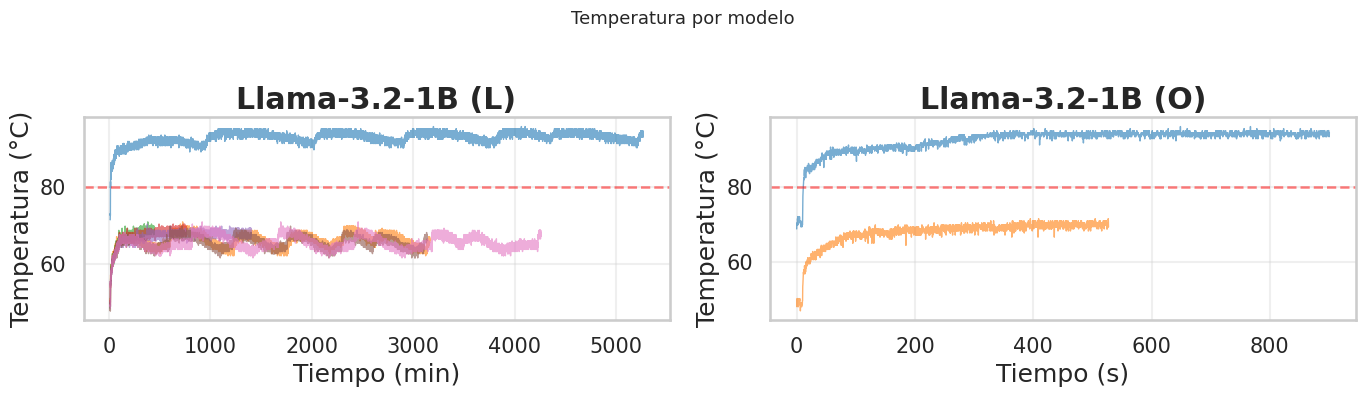

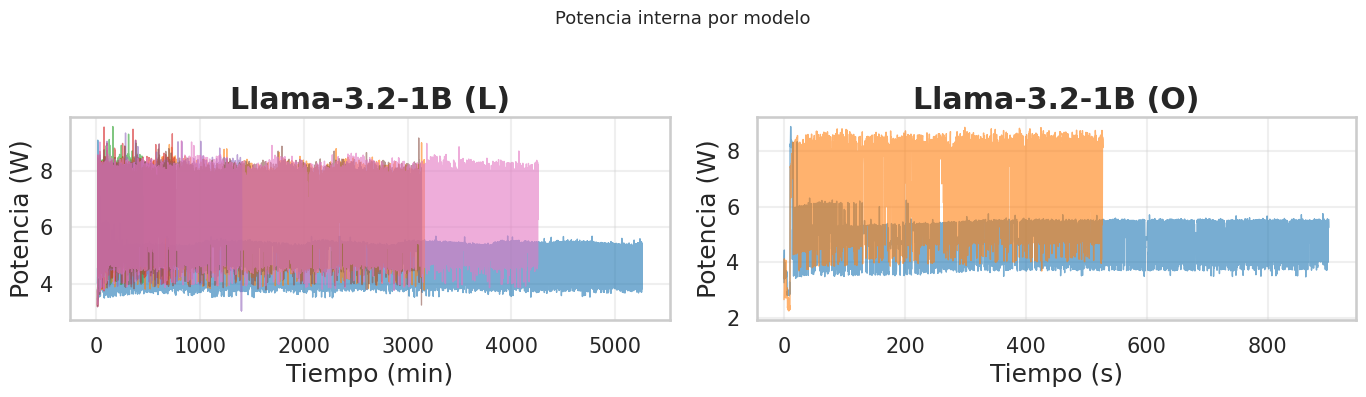

In [3]:
# Timelines de temperatura y potencia (small multiples, 2 columnas)
_run_ids = ex["run_id"].tolist() if "run_id" in ex.columns else []
hw_ex = hw_full[hw_full["run_id"].isin(_run_ids)] if "run_id" in hw_full.columns else pd.DataFrame()

def _plot_timeline(hw_ex, models, y_col, ylabel, suptitle, hline=None):
    ncols = 2
    nrows = (len(models) + 1) // ncols
    fig, axes = plt.subplots(nrows, ncols, figsize=(14, 4 * nrows))
    axes = axes.flatten() if hasattr(axes, 'flatten') else [axes]
    for ax, model in zip(axes, models):
        hw_m = hw_ex[hw_ex["model_label"] == model]
        if hw_m.empty:
            ax.text(0.5, 0.5, f"{model}\nSin datos", ha="center", va="center",
                    transform=ax.transAxes)
            ax.set_axis_off()
            continue
        # Plot each run separately (fast matplotlib lines, no seaborn aggregation)
        for rid in hw_m["run_id"].unique():
            sub = hw_m[hw_m["run_id"] == rid].sort_values("t_rel_s")
            ax.plot(sub["t_rel_s"].values, sub[y_col].values, alpha=0.6, linewidth=1)
        if hline is not None:
            ax.axhline(hline, ls="--", color="red", alpha=0.5)
        total_s = hw_m["t_rel_s"].max()
        ax.set_xlabel("Tiempo (min)" if total_s > 1800 else "Tiempo (s)")
        ax.set_ylabel(ylabel)
        ax.set_title(model, fontweight="bold")
        ax.grid(True, alpha=0.3)
    for ax in axes[len(models):]:
        ax.set_visible(False)
    fig.suptitle(suptitle, fontsize=13, y=1.01)
    fig.tight_layout()
    plt.show()

if not hw_ex.empty:
    models = sorted(ex["model_label"].unique())
    _plot_timeline(hw_ex, models, "temperature_c", "Temperatura (°C)",
                   "Temperatura por modelo", hline=80)
    _plot_timeline(hw_ex, models, "internal_power_w", "Potencia (W)",
                   "Potencia interna por modelo")
else:
    print("Sin datos de hardware para timelines")

/tmp/ipykernel_43556/98568102.py:14: UserWarning: set_ticklabels() should only be used with a fixed number of ticks, i.e. after set_ticks() or using a FixedLocator.
  axes[0].set_xticklabels(axes[0].get_xticklabels(), rotation=45, ha='right')
/tmp/ipykernel_43556/98568102.py:21: UserWarning: set_ticklabels() should only be used with a fixed number of ticks, i.e. after set_ticks() or using a FixedLocator.
  axes[1].set_xticklabels(axes[1].get_xticklabels(), rotation=45, ha='right')


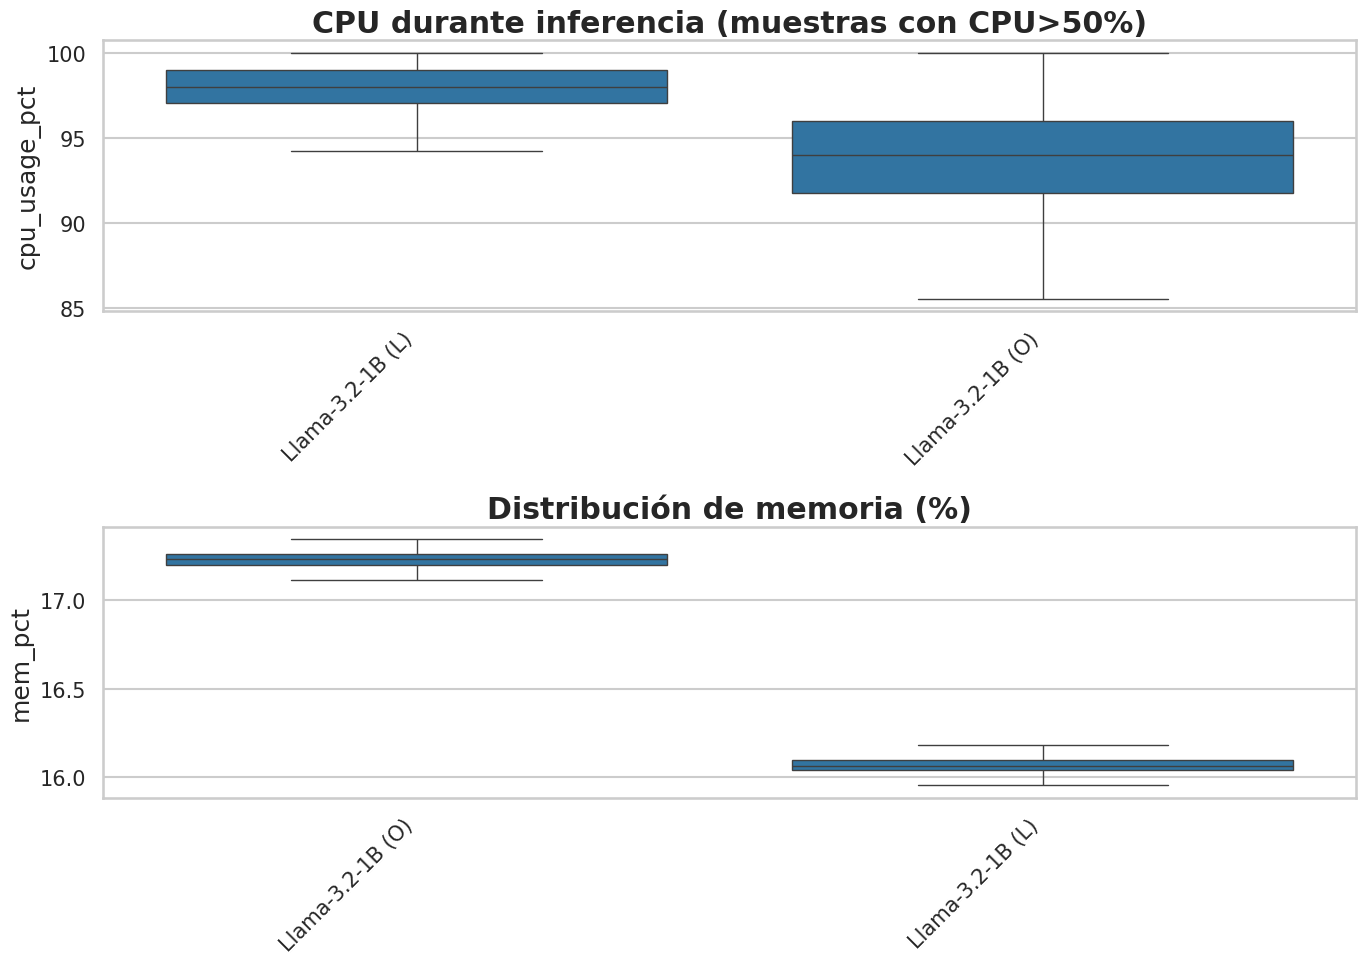

/tmp/ipykernel_43556/98568102.py:36: UserWarning: set_ticklabels() should only be used with a fixed number of ticks, i.e. after set_ticks() or using a FixedLocator.
  axes[0].set_xticklabels(axes[0].get_xticklabels(), rotation=45, ha='right')
/tmp/ipykernel_43556/98568102.py:45: UserWarning: set_ticklabels() should only be used with a fixed number of ticks, i.e. after set_ticks() or using a FixedLocator.
  axes[1].set_xticklabels(axes[1].get_xticklabels(), rotation=45, ha='right')


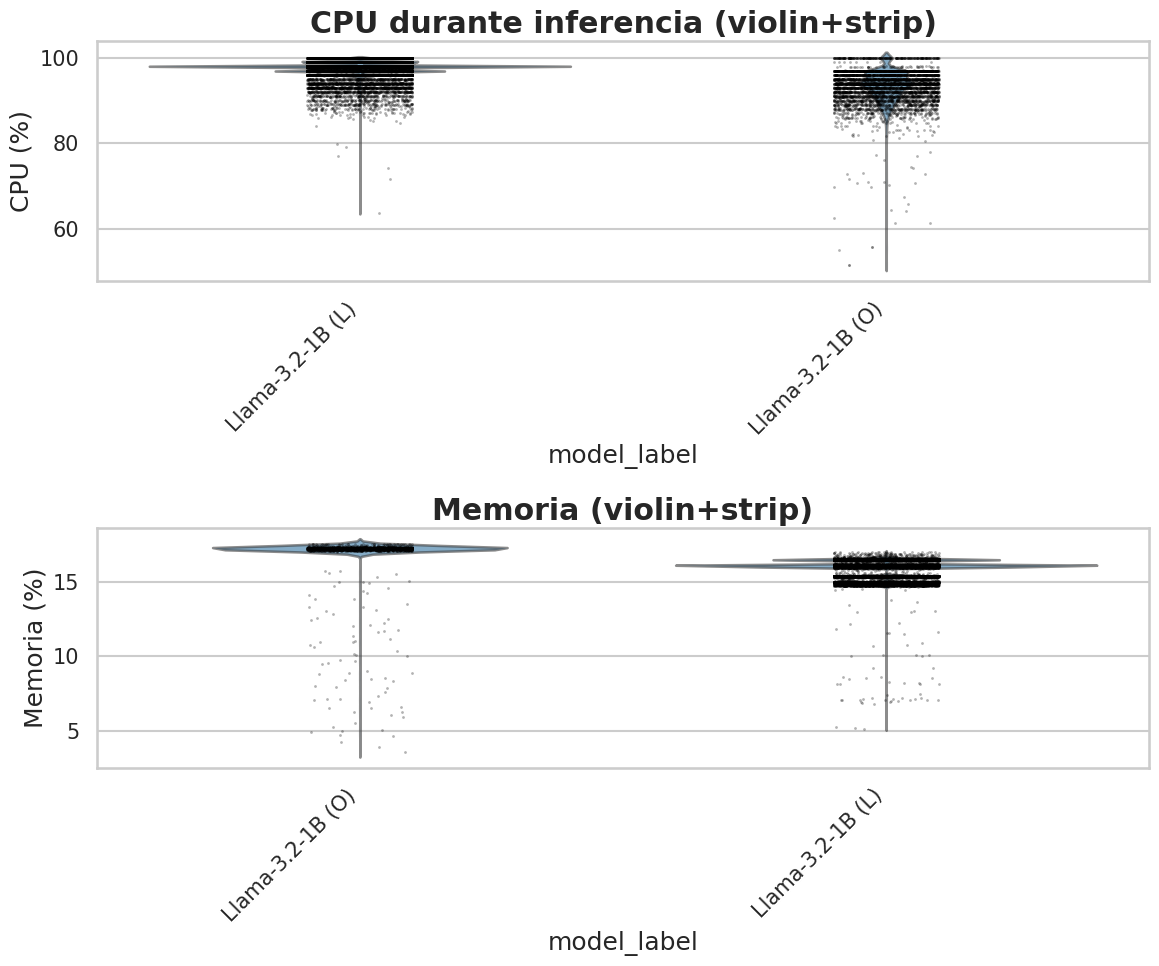

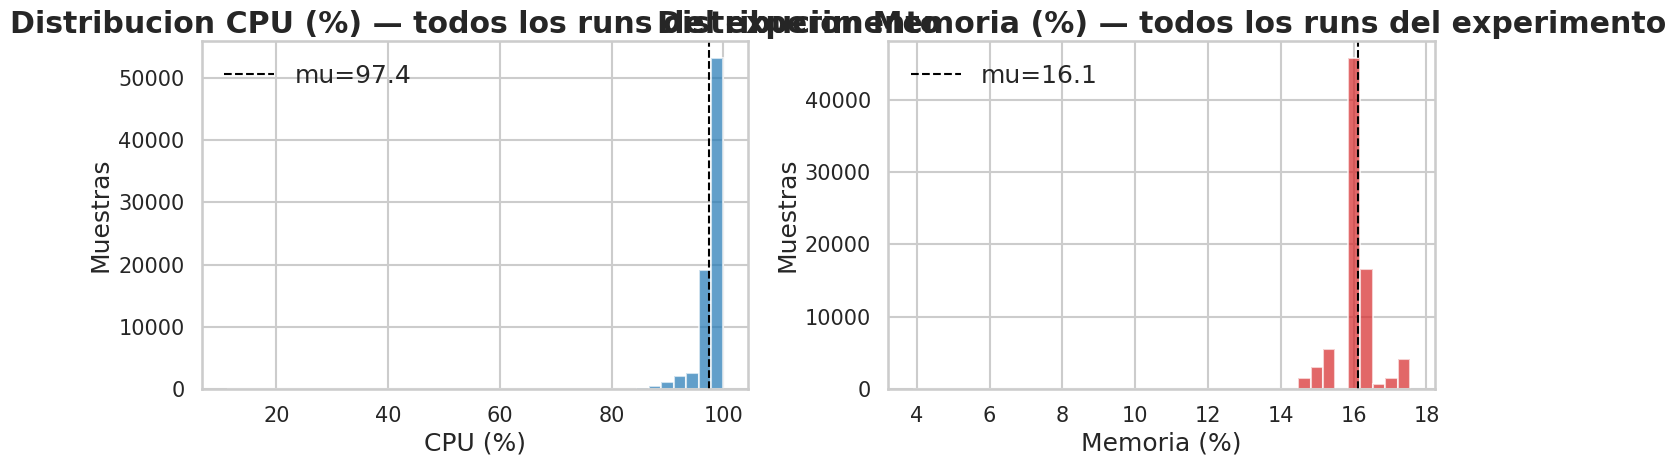

In [4]:
# Sección 5a — Boxplot CPU y Memoria
_run_ids = ex["run_id"].tolist() if "run_id" in ex.columns else []
hw_ex = hw_full[hw_full["run_id"].isin(_run_ids)] if "run_id" in hw_full.columns else pd.DataFrame()

if not hw_ex.empty:
    fig, axes = plt.subplots(2, 1, figsize=(14, 10))
    active = hw_ex[hw_ex["cpu_usage_pct"] > 50]
    order_cpu = (active.groupby("model_label")["cpu_usage_pct"]
                 .median().sort_values(ascending=False).index.tolist())
    sns.boxplot(data=active, x="model_label", y="cpu_usage_pct",
                order=order_cpu, showfliers=False, ax=axes[0])
    axes[0].set_title("CPU durante inferencia (muestras con CPU>50%)")
    axes[0].set_xlabel("")
    axes[0].set_xticklabels(axes[0].get_xticklabels(), rotation=45, ha='right')
    order_mem = (hw_ex.groupby("model_label")["mem_pct"]
                 .median().sort_values(ascending=False).index.tolist())
    sns.boxplot(data=hw_ex, x="model_label", y="mem_pct",
                order=order_mem, showfliers=False, ax=axes[1])
    axes[1].set_title("Distribución de memoria (%)")
    axes[1].set_xlabel("")
    axes[1].set_xticklabels(axes[1].get_xticklabels(), rotation=45, ha='right')
    fig.tight_layout()
    plt.show()

    # Sección 5b — Violin + strip
    fig, axes = plt.subplots(2, 1, figsize=(12, 10))
    active = hw_ex[hw_ex["cpu_usage_pct"] > 50]
    order_cpu = (active.groupby("model_label")["cpu_usage_pct"]
                 .median().sort_values(ascending=False).index
                 if not active.empty else [])
    if len(order_cpu) > 0:
        sns.violinplot(data=active, x="model_label", y="cpu_usage_pct",
                       order=order_cpu, inner=None, alpha=0.6, ax=axes[0])
        sns.stripplot(data=active, x="model_label", y="cpu_usage_pct",
                      order=order_cpu, size=2, alpha=0.3, color="black", ax=axes[0])
        axes[0].set_xticklabels(axes[0].get_xticklabels(), rotation=45, ha='right')
        axes[0].set_title("CPU durante inferencia (violin+strip)")
        axes[0].set_ylabel("CPU (%)")
    order_mem = (hw_ex.groupby("model_label")["mem_pct"]
                 .median().sort_values(ascending=False).index)
    sns.violinplot(data=hw_ex, x="model_label", y="mem_pct",
                   order=order_mem, inner=None, alpha=0.6, ax=axes[1])
    sns.stripplot(data=hw_ex, x="model_label", y="mem_pct",
                  order=order_mem, size=2, alpha=0.3, color="black", ax=axes[1])
    axes[1].set_xticklabels(axes[1].get_xticklabels(), rotation=45, ha='right')
    axes[1].set_title("Memoria (violin+strip)")
    axes[1].set_ylabel("Memoria (%)")
    fig.tight_layout()
    plt.show()

    # Sección 5c — Histogramas agregados
    fig, axes = plt.subplots(1, 2, figsize=(14, 5))
    for ax, (col, xlabel, color) in zip(axes, [
        ("cpu_usage_pct", "CPU (%)", "tab:blue"),
        ("mem_pct", "Memoria (%)", "tab:red"),
    ]):
        active_hist = hw_ex[hw_ex["cpu_usage_pct"] > 10]
        data = active_hist[col].dropna()
        if not data.empty:
            ax.hist(data, bins=40, color=color, alpha=0.7, edgecolor='white')
            ax.axvline(data.mean(), color='black', ls='--', lw=1.5,
                       label=f"mu={data.mean():.1f}")
            ax.set_xlabel(xlabel)
            ax.set_ylabel("Muestras")
            ax.set_title(f"Distribucion {xlabel} — todos los runs del experimento")
            ax.legend()
    fig.tight_layout()
    plt.show()
else:
    print("Sin datos de hardware para distribuciones CPU/Memoria")

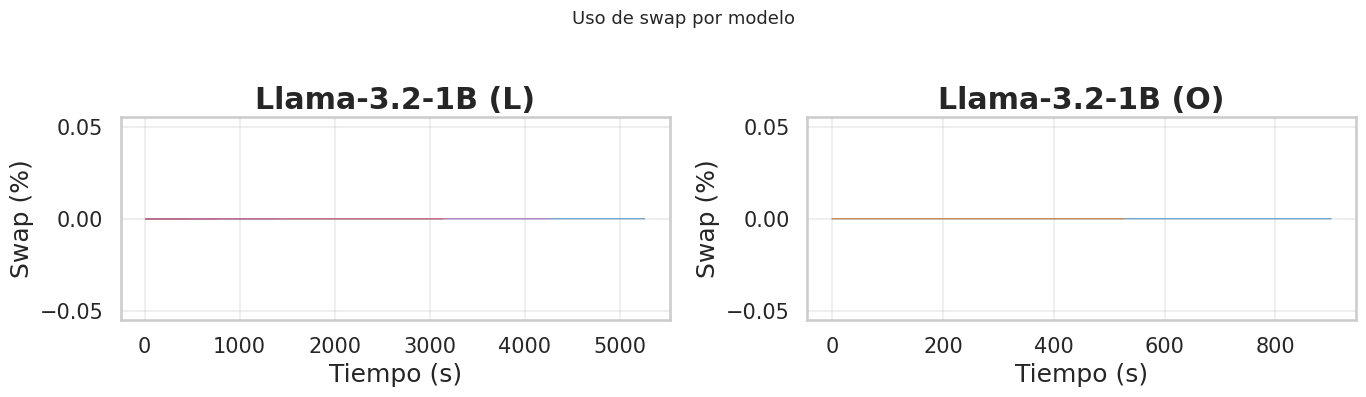

In [5]:
# Swap por modelo (small multiples)
_run_ids = ex["run_id"].tolist() if "run_id" in ex.columns else []
hw_ex = hw_full[hw_full["run_id"].isin(_run_ids)] if "run_id" in hw_full.columns else pd.DataFrame()

if not hw_ex.empty:
    models = sorted(ex["model_label"].unique())
    ncols = 2
    nrows = (len(models) + 1) // ncols
    fig, axes = plt.subplots(nrows, ncols, figsize=(14, 4 * nrows))
    axes = axes.flatten() if hasattr(axes, 'flatten') else [axes]
    for ax, model in zip(axes, models):
        hw_m = hw_ex[hw_ex["model_label"] == model]
        if hw_m.empty:
            ax.text(0.5, 0.5, f"{model}\nSin datos", ha="center", va="center",
                    transform=ax.transAxes)
            ax.set_axis_off()
            continue
        for rid in hw_m["run_id"].unique():
            sub = hw_m[hw_m["run_id"] == rid].sort_values("t_rel_s")
            ax.plot(sub["t_rel_s"].values, sub["swap_pct"].values, alpha=0.6, linewidth=1)
        ax.set_xlabel("Tiempo (s)")
        ax.set_ylabel("Swap (%)")
        ax.set_title(model, fontweight="bold")
        ax.grid(True, alpha=0.3)
    for ax in axes[len(models):]:
        ax.set_visible(False)
    fig.suptitle("Uso de swap por modelo", fontsize=13, y=1.01)
    fig.tight_layout()
    plt.show()
else:
    print("Sin datos de hardware para swap")

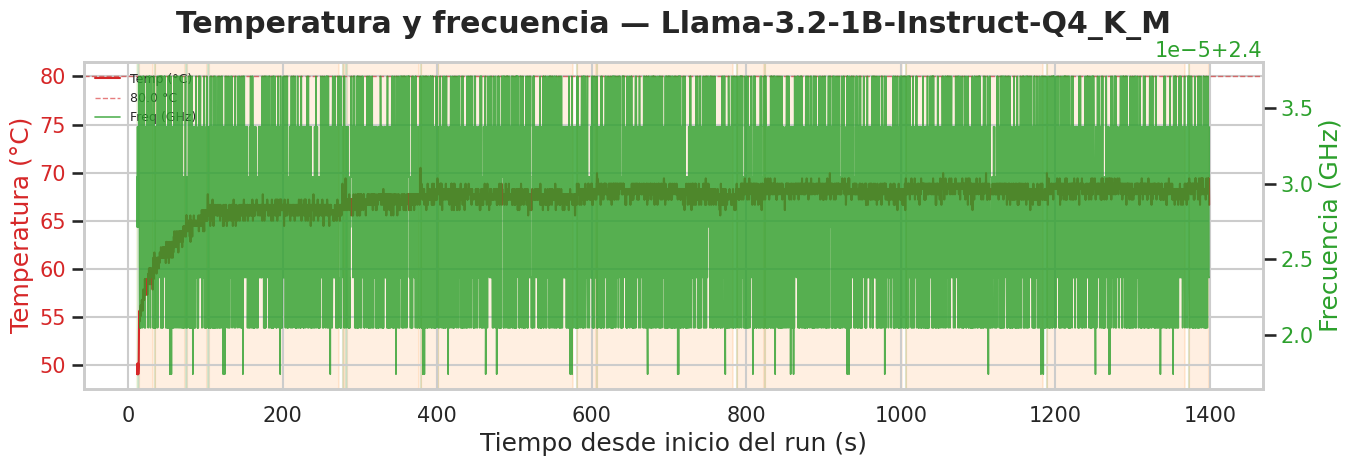

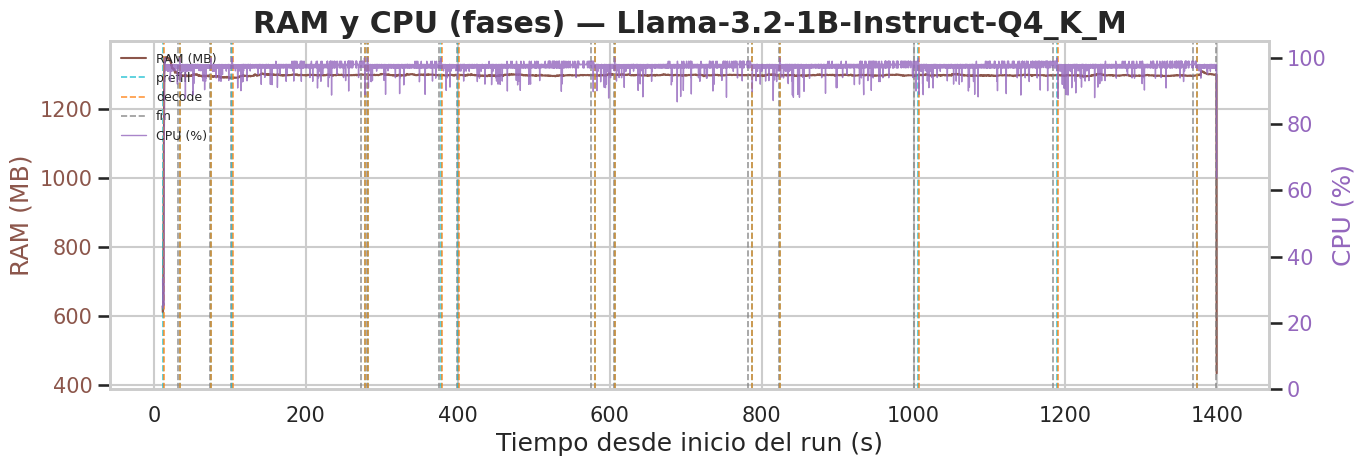

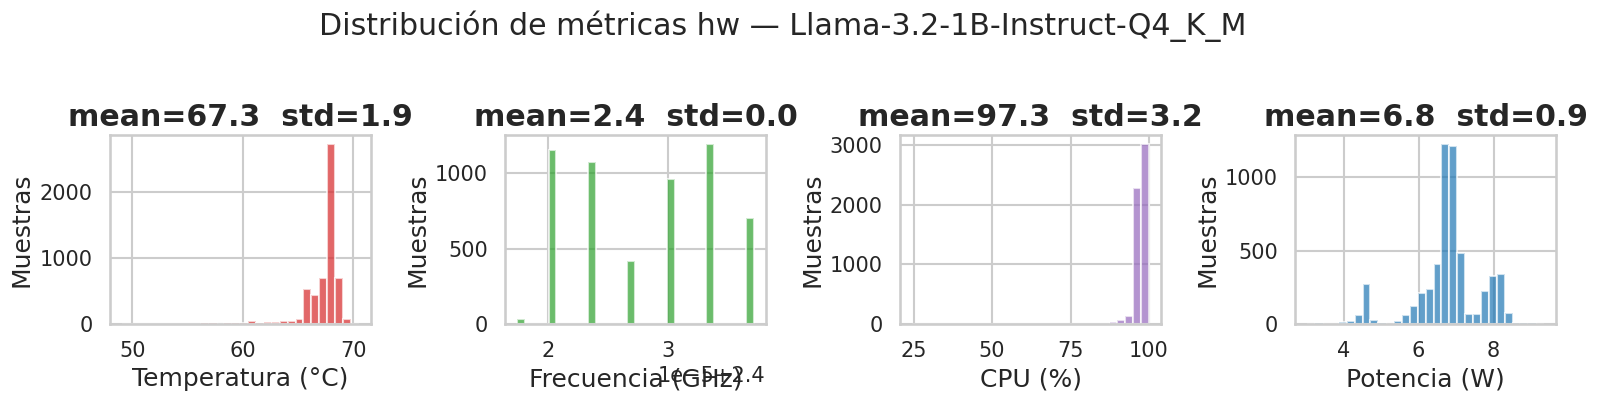

In [6]:
# Análisis detallado de un run representativo (mediana de duración)
from monitorviz.viz import temp_freq_dual, cpu_memory_dual_phases, hw_distributions_panel

_run_ids = ex["run_id"].tolist() if "run_id" in ex.columns else []
hw_ex = hw_full[hw_full["run_id"].isin(_run_ids)] if "run_id" in hw_full.columns else pd.DataFrame()

if not hw_ex.empty and len(ex) > 0:
    run_durations = hw_ex.groupby("run_id")["t_rel_s"].max().sort_values()
    median_idx = len(run_durations) // 2
    representative_run_id = run_durations.index[median_idx]
    representative_run = next((r for r in coll.runs if r.run_id == representative_run_id), None)
    if representative_run:
        hw_r = hw_ex[hw_ex["run_id"] == representative_run_id]
        try:
            fig = temp_freq_dual(hw_r, representative_run)
            plt.show()
        except Exception as e:
            print(f"temp_freq_dual: {e}")
        try:
            fig = cpu_memory_dual_phases(hw_r, representative_run)
            plt.show()
        except Exception as e:
            print(f"cpu_memory_dual_phases: {e}")
        try:
            fig = hw_distributions_panel(hw_r, representative_run)
            plt.show()
        except Exception as e:
            print(f"hw_distributions_panel: {e}")
    else:
        print("No se encontro run representativo")
else:
    print("Sin datos para análisis detallado")

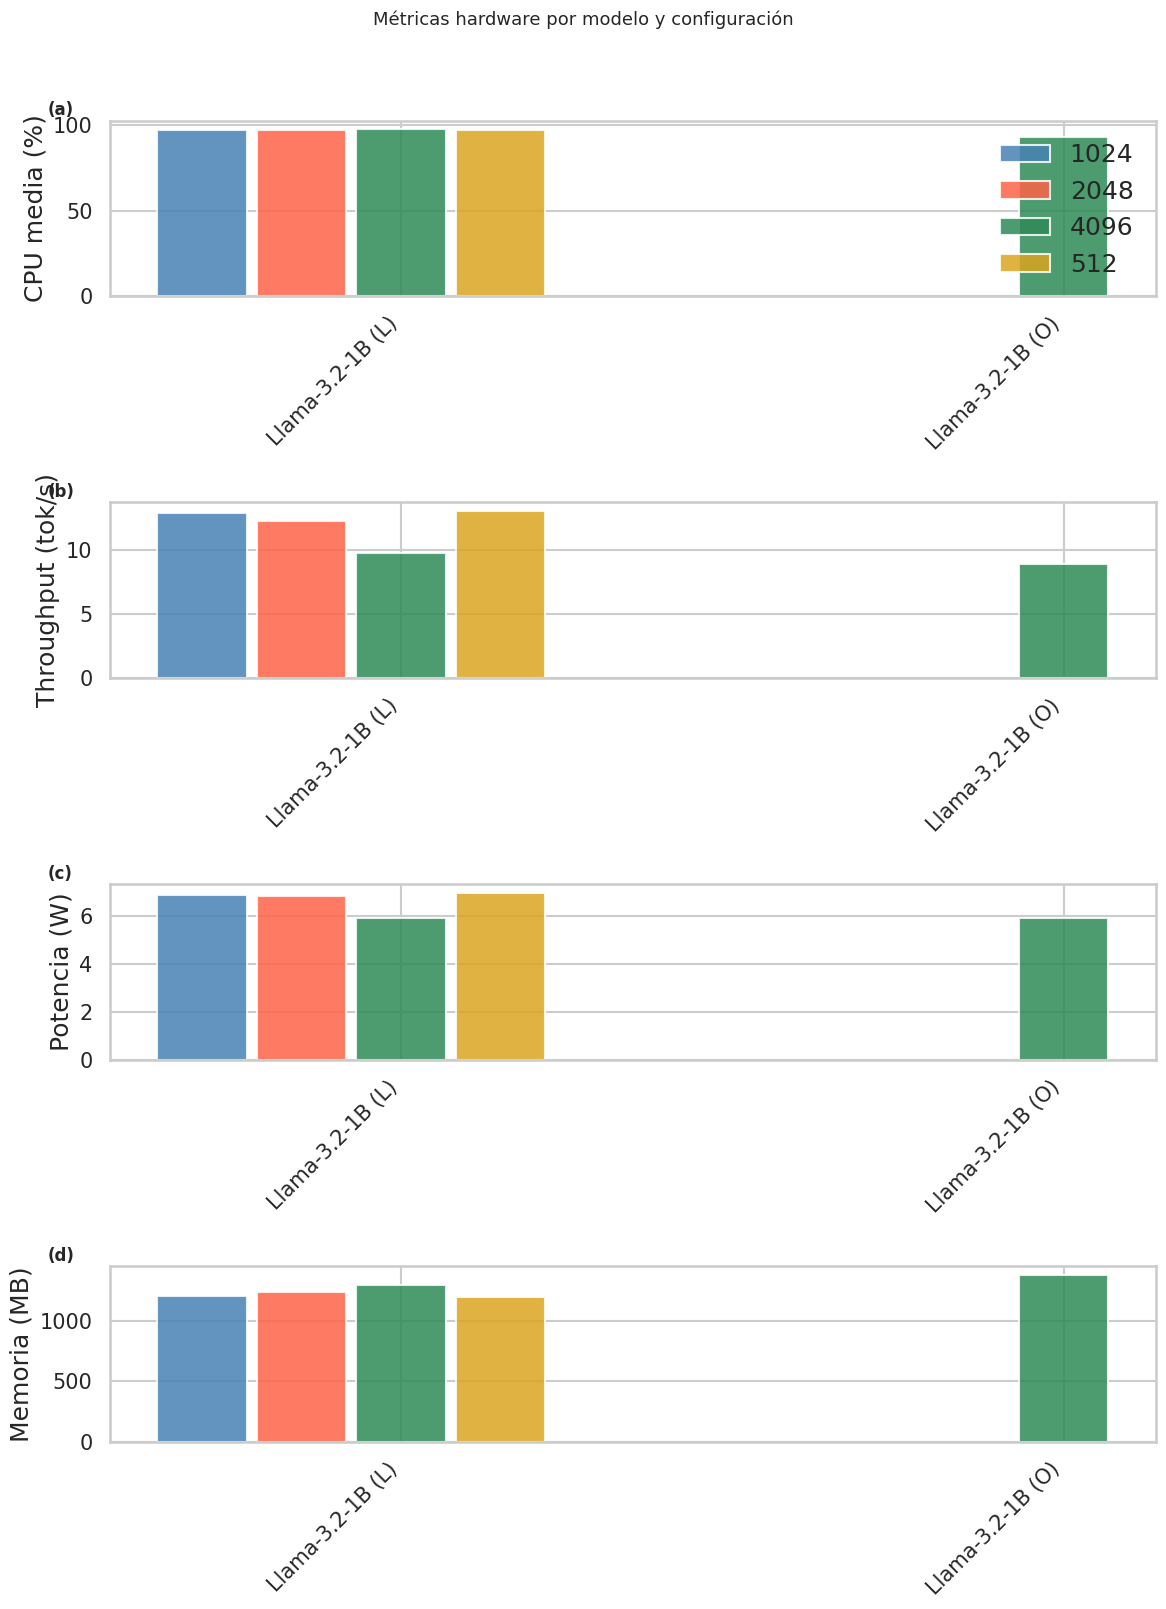

In [7]:
# Grouped bar chart hardware (4 paneles: CPU%, Throughput, Potencia, Memoria)
import re

_run_ids = ex["run_id"].tolist() if "run_id" in ex.columns else []
hw_ex = hw_full[hw_full["run_id"].isin(_run_ids)] if "run_id" in hw_full.columns else pd.DataFrame()

hw_summary_rows = []
pm_valid_tmp = (pm_full[
    (pm_full["run_id"].isin(_run_ids)) &
    (~pm_full["is_empty_generation"]) &
    (pm_full["latency_ms"] > 0)
] if "run_id" in pm_full.columns else pd.DataFrame())
for _, row in ex.iterrows():
    if "run_id" not in row.index:
        continue
    hw_r = hw_ex[hw_ex["run_id"] == row["run_id"]] if "run_id" in hw_ex.columns else pd.DataFrame()
    pm_r = pm_valid_tmp[pm_valid_tmp["run_id"] == row["run_id"]] if "run_id" in pm_valid_tmp.columns else pd.DataFrame()
    if hw_r.empty:
        continue
    active_r = hw_r[hw_r["cpu_usage_pct"] > 50]
    group_label = str(int(row.get("context_size", 0))) if not pd.isna(row.get("context_size", float("nan"))) else "?"
    hw_summary_rows.append({
        "model": row["model_label"],
        "config": group_label,
        "cpu_pct": active_r["cpu_usage_pct"].mean() if not active_r.empty else float("nan"),
        "tokens_s": pm_r["tokens_per_second"].mean() if not pm_r.empty else float("nan"),
        "power_w": hw_r["internal_power_w"].mean(),
        "mem_mb": hw_r["mem_used_bytes"].mean() / (1024**2) if not hw_r.empty else float("nan"),
    })

if hw_summary_rows:
    hw_summary = pd.DataFrame(hw_summary_rows)
    METRICS = [
        ("cpu_pct",  "CPU media (%)",      "(a)"),
        ("tokens_s", "Throughput (tok/s)", "(b)"),
        ("power_w",  "Potencia (W)",       "(c)"),
        ("mem_mb",   "Memoria (MB)",       "(d)"),
    ]
    models  = sorted(hw_summary["model"].unique())
    configs = sorted(hw_summary["config"].unique())
    x_pos   = np.arange(len(models))
    n_cfg   = len(configs)
    width   = 0.75 / max(n_cfg, 1)
    colors  = ["steelblue", "tomato", "seagreen", "goldenrod"]
    fig, axes = plt.subplots(len(METRICS), 1, figsize=(12, 4 * len(METRICS)))
    for i, (ax, (col, ylabel, label)) in enumerate(zip(axes, METRICS)):
        data = hw_summary.dropna(subset=[col])
        for j, (cfg, color) in enumerate(zip(configs, colors)):
            vals = [data[(data["model"] == m) & (data["config"] == cfg)][col].mean()
                    for m in models]
            offset = (j - n_cfg / 2 + 0.5) * width
            ax.bar(x_pos + offset, vals, width * 0.9, label=cfg, color=color, alpha=0.85)
        ax.set_xticks(x_pos)
        ax.set_xticklabels(models, rotation=45, ha='right')
        ax.set_ylabel(ylabel)
        ax.text(-0.06, 1.03, label, transform=ax.transAxes, fontweight="bold", fontsize=12)
        if col == "cpu_pct":
            ax.legend(loc="upper right")
    fig.suptitle("Métricas hardware por modelo y configuración", y=1.01, fontsize=13)
    fig.tight_layout()
    plt.show()
else:
    print("Sin datos para grouped bar chart hardware")

/tmp/ipykernel_43556/1277010892.py:12: UserWarning: set_ticklabels() should only be used with a fixed number of ticks, i.e. after set_ticks() or using a FixedLocator.
  ax.set_xticklabels(ax.get_xticklabels(), rotation=45, ha='right')


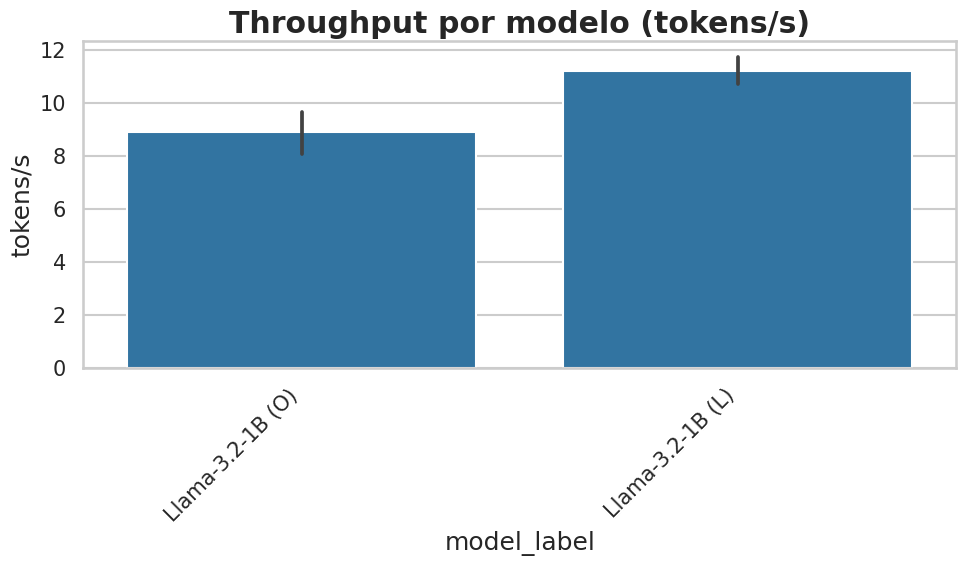

/tmp/ipykernel_43556/1277010892.py:12: UserWarning: set_ticklabels() should only be used with a fixed number of ticks, i.e. after set_ticks() or using a FixedLocator.
  ax.set_xticklabels(ax.get_xticklabels(), rotation=45, ha='right')


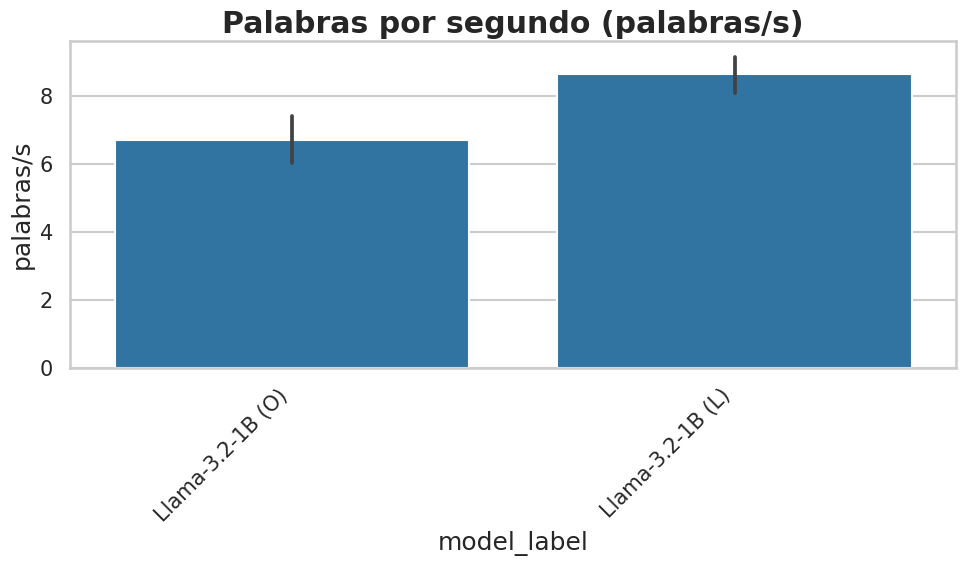

/tmp/ipykernel_43556/1277010892.py:12: UserWarning: set_ticklabels() should only be used with a fixed number of ticks, i.e. after set_ticks() or using a FixedLocator.
  ax.set_xticklabels(ax.get_xticklabels(), rotation=45, ha='right')


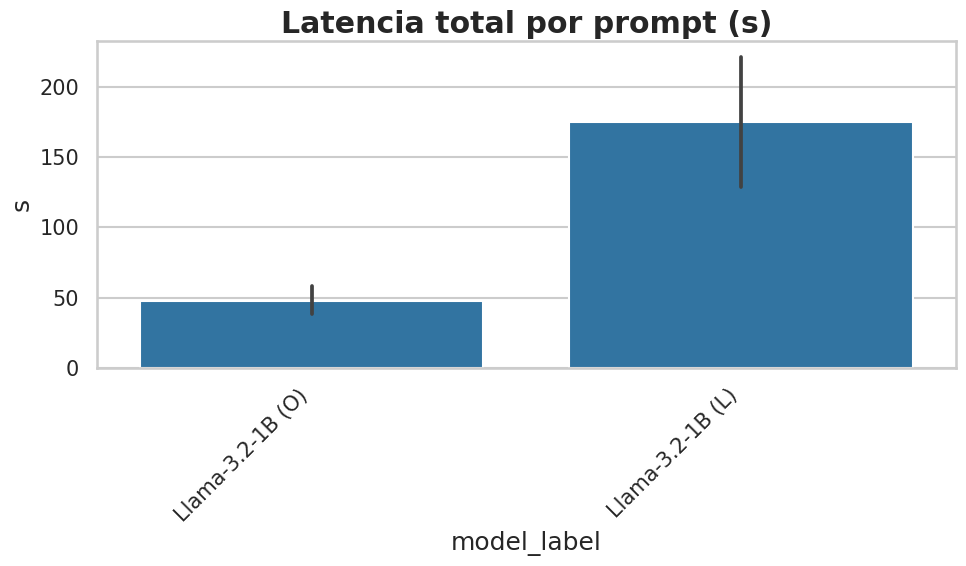

/tmp/ipykernel_43556/1277010892.py:12: UserWarning: set_ticklabels() should only be used with a fixed number of ticks, i.e. after set_ticks() or using a FixedLocator.
  ax.set_xticklabels(ax.get_xticklabels(), rotation=45, ha='right')


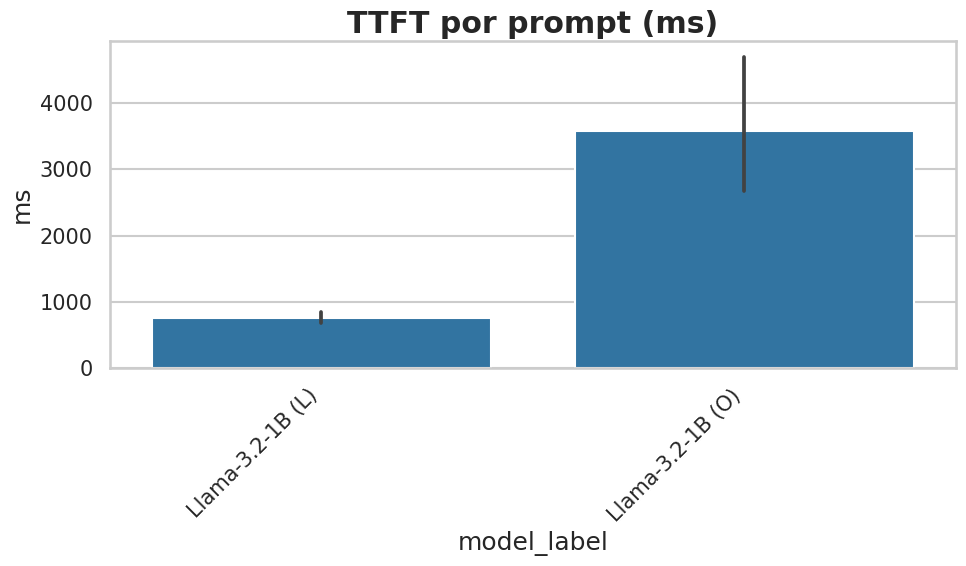

/tmp/ipykernel_43556/1277010892.py:12: UserWarning: set_ticklabels() should only be used with a fixed number of ticks, i.e. after set_ticks() or using a FixedLocator.
  ax.set_xticklabels(ax.get_xticklabels(), rotation=45, ha='right')


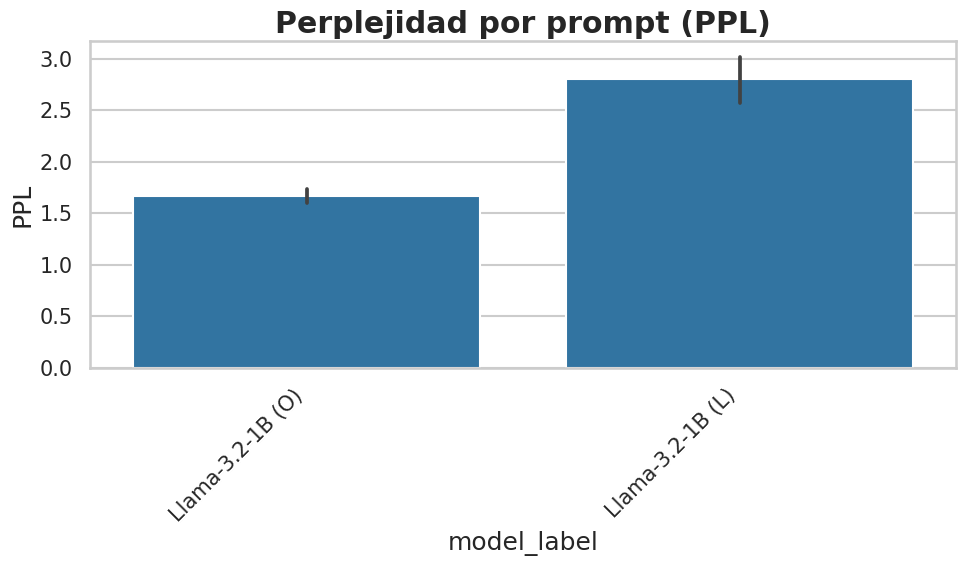

In [8]:
# Métricas de inferencia por modelo
def _plot_metric(df, metric, ylabel, title, unit_divisor=1.0, unit_label="", order=None):
    data = df.dropna(subset=[metric]).copy()
    data["_val"] = data[metric] / unit_divisor
    counts = data.groupby("model_label")["_val"].count()
    min_n = counts.min() if not counts.empty else 0
    _order = order or data.groupby("model_label")["_val"].mean().sort_values().index.tolist()
    full_title = f"{title}" + (f" ({unit_label})" if unit_label else "")
    if min_n >= 3:
        fig, ax = plt.subplots(figsize=(10, 6))
        sns.barplot(data=data, x="model_label", y="_val", order=_order, ax=ax)
        ax.set_xticklabels(ax.get_xticklabels(), rotation=45, ha='right')
        ax.set_ylabel(unit_label or metric)
        ax.set_title(full_title)
        fig.tight_layout()
    else:
        means = data.groupby("model_label")["_val"].mean().reindex(_order)
        fig, ax = plt.subplots(figsize=(10, max(6, len(means) * 0.4)))
        ax.barh(range(len(means)), means, alpha=0.7)
        ax.set_yticks(range(len(means)))
        ax.set_yticklabels(means.index)
        ax.set_title(full_title)
        fig.tight_layout()
    plt.show()

_run_ids_pm = ex["run_id"].tolist() if "run_id" in ex.columns else []
pm_valid = (pm_full[
    (pm_full["run_id"].isin(_run_ids_pm)) &
    (~pm_full["is_empty_generation"]) &
    (pm_full["latency_ms"] > 0)
].copy() if "run_id" in pm_full.columns else pd.DataFrame())

if not pm_valid.empty:
    _plot_metric(pm_valid, "tokens_per_second", "tokens/s", "Throughput por modelo",
                 unit_label="tokens/s")
    _plot_metric(pm_valid, "words_per_second", "palabras/s", "Palabras por segundo",
                 unit_label="palabras/s")
    _plot_metric(pm_valid, "latency_ms", "ms", "Latencia total por prompt",
                 unit_divisor=1000, unit_label="s")
    _plot_metric(pm_valid, "time_to_first_token_ms", "ms", "TTFT por prompt",
                 unit_label="ms")
    ppl_valid = pm_valid.dropna(subset=["perplexity"])
    if not ppl_valid.empty:
        _plot_metric(ppl_valid, "perplexity", "", "Perplejidad por prompt",
                     unit_label="PPL")
else:
    print("Sin datos de inferencia")

/tmp/ipykernel_43556/870363815.py:14: UserWarning: No artists with labels found to put in legend.  Note that artists whose label start with an underscore are ignored when legend() is called with no argument.
  ax.legend(title="Modelo", bbox_to_anchor=(1.05, 1), loc="upper left", fontsize=9)


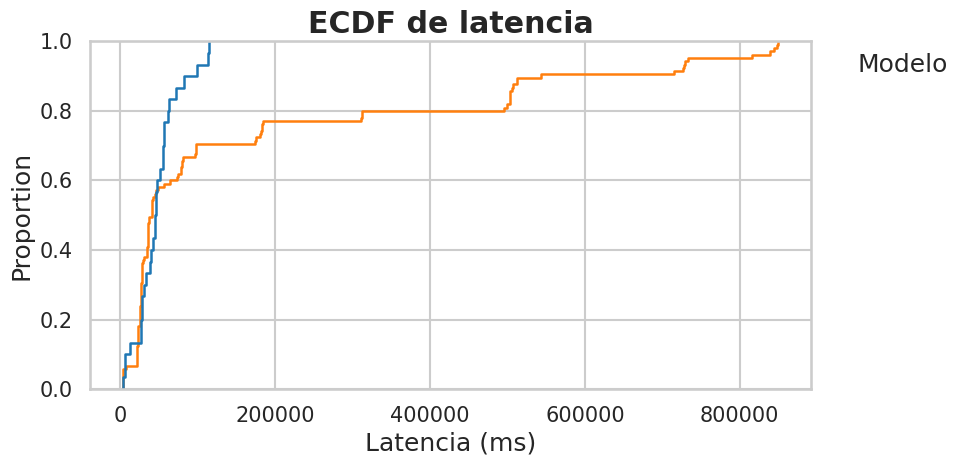

/tmp/ipykernel_43556/870363815.py:24: UserWarning: No artists with labels found to put in legend.  Note that artists whose label start with an underscore are ignored when legend() is called with no argument.
  ax.legend(title="Modelo", bbox_to_anchor=(1.05, 1), loc="upper left", fontsize=9)


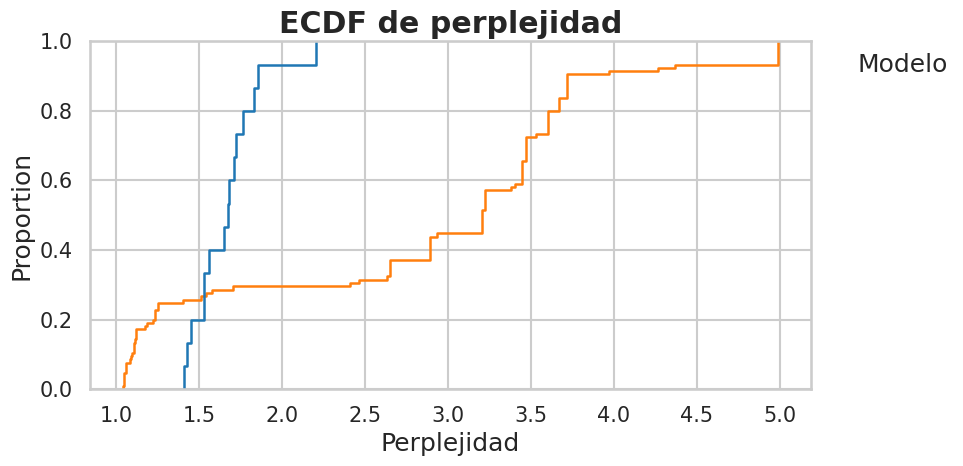

In [9]:
# ECDFs de latencia y perplejidad
_run_ids_pm = ex["run_id"].tolist() if "run_id" in ex.columns else []
pm_valid = (pm_full[
    (pm_full["run_id"].isin(_run_ids_pm)) &
    (~pm_full["is_empty_generation"]) &
    (pm_full["latency_ms"] > 0)
].copy() if "run_id" in pm_full.columns else pd.DataFrame())

if not pm_valid.empty:
    fig, ax = plt.subplots(figsize=(10, 5))
    sns.ecdfplot(data=pm_valid, x="latency_ms", hue="model_label", ax=ax)
    ax.set_title("ECDF de latencia")
    ax.set_xlabel("Latencia (ms)")
    ax.legend(title="Modelo", bbox_to_anchor=(1.05, 1), loc="upper left", fontsize=9)
    fig.tight_layout()
    plt.show()

    ppl_valid = pm_valid.dropna(subset=["perplexity"])
    if not ppl_valid.empty:
        fig, ax = plt.subplots(figsize=(10, 5))
        sns.ecdfplot(data=ppl_valid, x="perplexity", hue="model_label", ax=ax)
        ax.set_title("ECDF de perplejidad")
        ax.set_xlabel("Perplejidad")
        ax.legend(title="Modelo", bbox_to_anchor=(1.05, 1), loc="upper left", fontsize=9)
        fig.tight_layout()
        plt.show()
else:
    print("Sin datos para ECDFs")

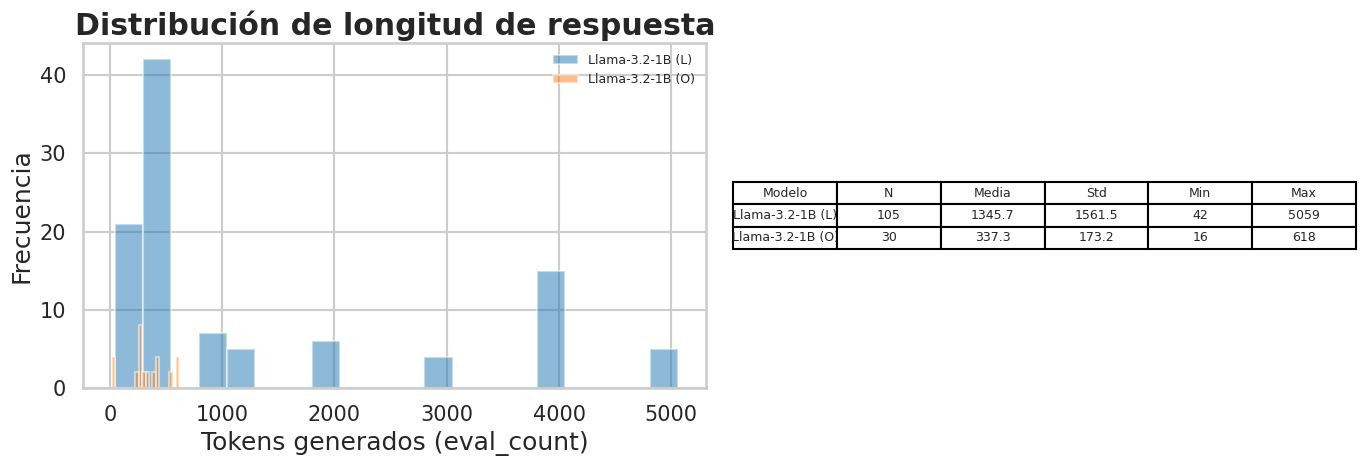

In [10]:
# Distribución de longitud de respuesta
_run_ids_pm = ex["run_id"].tolist() if "run_id" in ex.columns else []
pm_valid = (pm_full[
    (pm_full["run_id"].isin(_run_ids_pm)) &
    (~pm_full["is_empty_generation"]) &
    (pm_full["latency_ms"] > 0)
].copy() if "run_id" in pm_full.columns else pd.DataFrame())

if not pm_valid.empty:
    fig, axes = plt.subplots(1, 2, figsize=(14, 5))
    for model in sorted(pm_valid["model_label"].unique()):
        sub = pm_valid[pm_valid["model_label"] == model]
        axes[0].hist(sub["eval_count"], bins=20, alpha=0.5, label=model)
    axes[0].set_xlabel("Tokens generados (eval_count)")
    axes[0].set_ylabel("Frecuencia")
    axes[0].set_title("Distribución de longitud de respuesta")
    axes[0].legend(fontsize=9)
    summary_resp = pm_valid.groupby("model_label")["eval_count"].agg(
        count="count", mean="mean", std="std", min="min", max="max"
    ).round(1).sort_values("mean", ascending=False)
    axes[1].axis("off")
    table_data = [["Modelo", "N", "Media", "Std", "Min", "Max"]]
    for idx, row in summary_resp.iterrows():
        table_data.append([idx, int(row["count"]), f"{row['mean']:.1f}",
                           f"{row['std']:.1f}", f"{row['min']:.0f}", f"{row['max']:.0f}"])
    t = axes[1].table(cellText=table_data, loc="center", cellLoc="center")
    t.auto_set_font_size(False)
    t.set_fontsize(9)
    t.scale(1, 1.5)
    fig.tight_layout()
    plt.show()
else:
    print("Sin datos para distribución de longitud de respuesta")

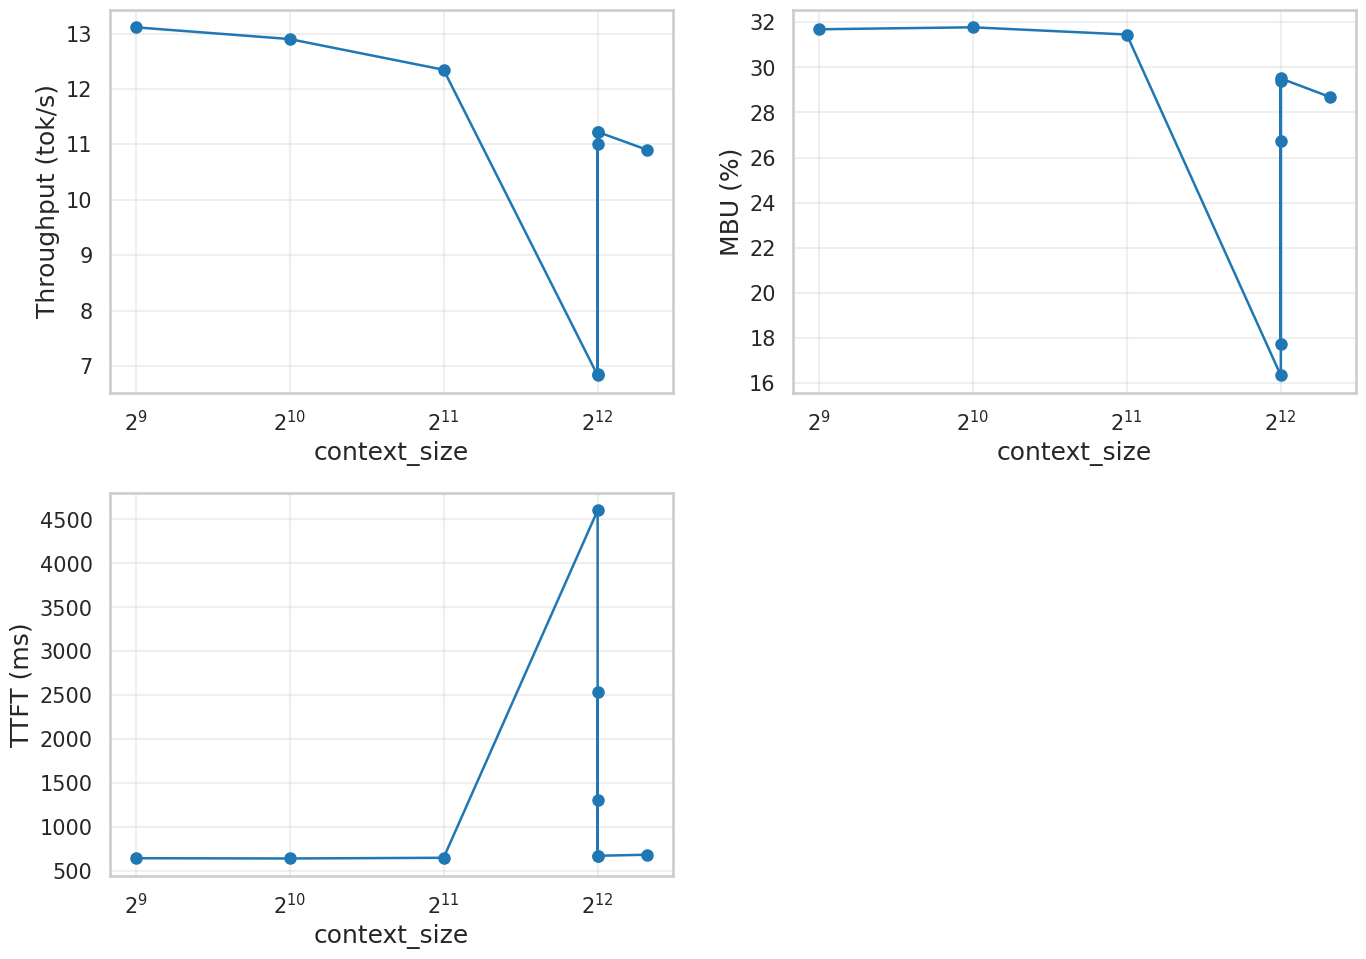

In [11]:
# Análisis específico E2: Context size sensitivity
try:
    from monitorviz.viz import sensitivity_curve
    e2_ok = not ex.empty and "context_size" in ex.columns and ex["context_size"].nunique() >= 2
    if e2_ok:
        fig = sensitivity_curve(ex, param_col="context_size", metrics=[
            ("tokens_per_s_mean", "Throughput (tok/s)"),
            ("mbu_pct", "MBU (%)"),
            ("ttft_ms_mean", "TTFT (ms)"),
        ], log_x=True)
        plt.show()
    else:
        print("Sin datos de context_size")
except Exception as e:
    print(f"Error sensitivity_curve: {e}")

/tmp/ipykernel_43556/1864559145.py:8: UserWarning: set_ticklabels() should only be used with a fixed number of ticks, i.e. after set_ticks() or using a FixedLocator.
  ax.set_xticklabels(ax.get_xticklabels(), rotation=45, ha='right')


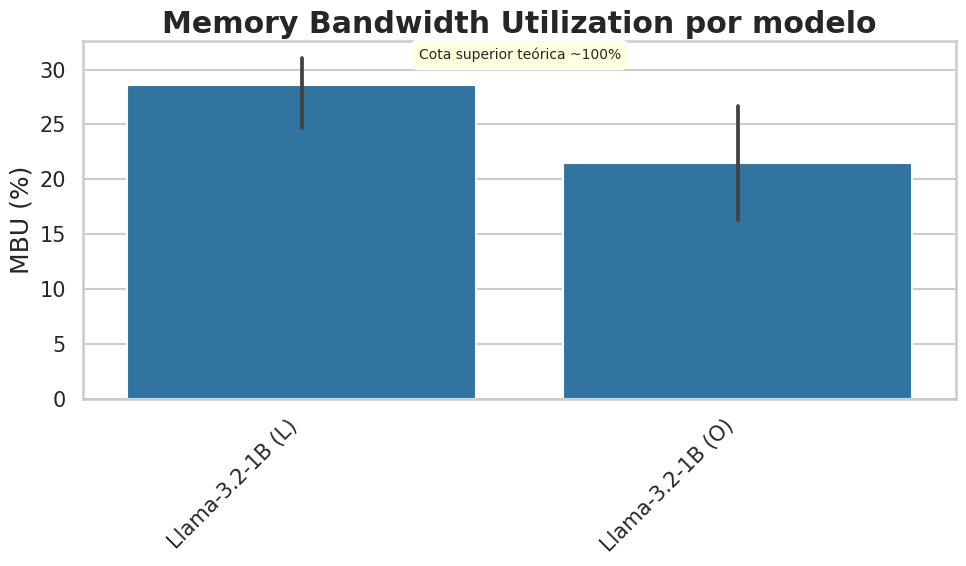

In [12]:
# MBU — Memory Bandwidth Utilization
if "mbu_pct" in ex.columns:
    mbu_data = ex.dropna(subset=["mbu_pct"])
    if not mbu_data.empty:
        fig, ax = plt.subplots(figsize=(10, 6))
        order = mbu_data.groupby("model_label")["mbu_pct"].mean().sort_values(ascending=False).index
        sns.barplot(data=mbu_data, x="model_label", y="mbu_pct", order=order, ax=ax)
        ax.set_xticklabels(ax.get_xticklabels(), rotation=45, ha='right')
        ax.set_ylabel("MBU (%)")
        ax.set_xlabel("")
        ax.set_title("Memory Bandwidth Utilization por modelo")
        ax.text(0.5, 0.95, "Cota superior teórica ~100%", transform=ax.transAxes,
                ha="center", fontsize=10, bbox=dict(boxstyle="round,pad=0.5", facecolor="lightyellow"))
        fig.tight_layout()
        plt.show()
    else:
        print("Sin datos de MBU")
else:
    print("Sin columna mbu_pct")

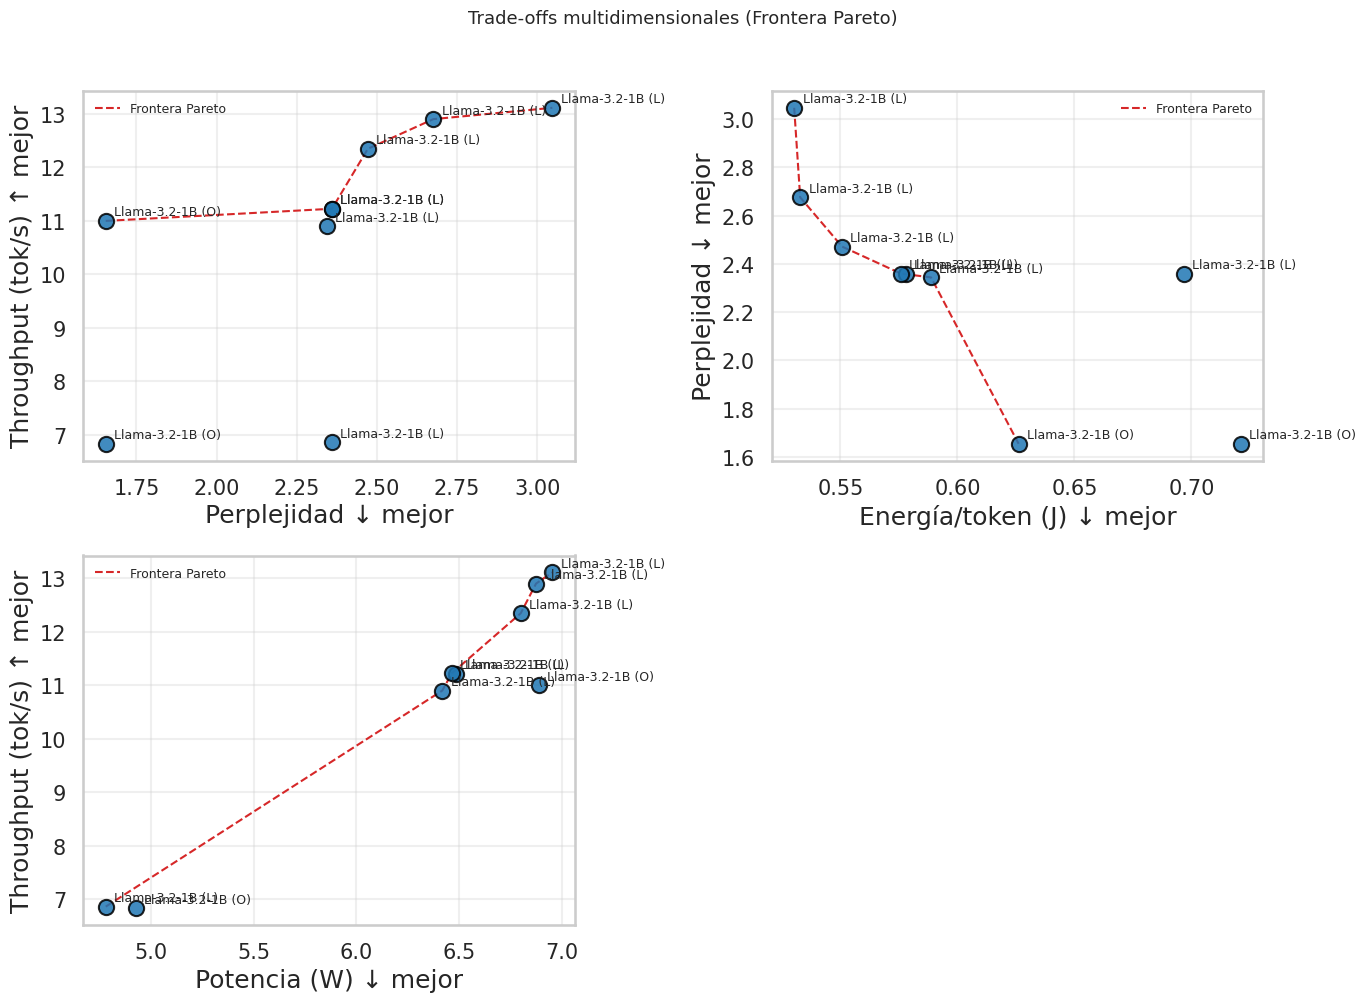

In [13]:
# Trade-offs multidimensionales — Frontera de Pareto
try:
    from monitorviz.viz import pareto_panel_multi
    pareto_pairs = [
        ("perplexity_geomean", "tokens_per_s_mean", "Perplejidad", "Throughput (tok/s)", True, False),
        ("energy_per_token_j", "perplexity_geomean", "Energía/token (J)", "Perplejidad", True, True),
        ("power_mean_w", "tokens_per_s_mean", "Potencia (W)", "Throughput (tok/s)", True, False),
    ]
    valid_pairs = [(p, q, pl, ql, *rest) for p, q, pl, ql, *rest in pareto_pairs
                   if p in ex.columns and q in ex.columns]
    if valid_pairs and not ex.empty:
        fig = pareto_panel_multi(ex, valid_pairs, label_col="model_label",
                                 title="Trade-offs multidimensionales (Frontera Pareto)")
        plt.show()
    else:
        print("Columnas insuficientes para Pareto")
except Exception as e:
    print(f"Error en Pareto: {e}")

In [14]:
# Desglose de fases (si hay datos)
try:
    from monitorviz.viz import phase_breakdown_stacked
    _run_ids_15 = ex["run_id"].tolist() if "run_id" in ex.columns else []
    pm_valid = (pm_full[
        (pm_full["run_id"].isin(_run_ids_15)) &
        (~pm_full["is_empty_generation"]) &
        (pm_full["latency_ms"] > 0)
    ] if "run_id" in pm_full.columns else pd.DataFrame())
    if not pm_valid.empty and "phase_prompt_s" in pm_valid.columns:
        fig = phase_breakdown_stacked(ex, normalized=True)
        plt.show()
        fig = phase_breakdown_stacked(ex, normalized=False)
        plt.show()
    else:
        print("Sin datos de fases")
except Exception as e:
    print(f"Error en phase_breakdown: {e}")

Sin datos de fases


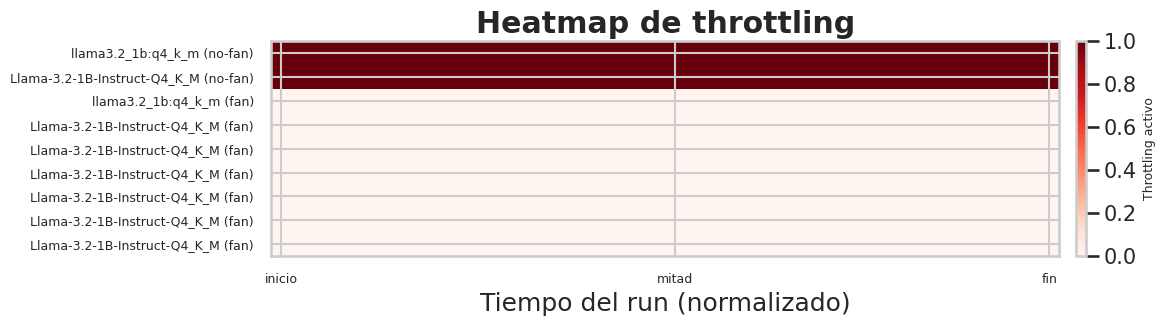

In [15]:
# Throttling heatmap
try:
    from monitorviz.viz import throttling_heatmap
    _run_ids_16 = ex["run_id"].tolist() if "run_id" in ex.columns else []
    hw_ex = hw_full[hw_full["run_id"].isin(_run_ids_16)] if "run_id" in hw_full.columns else pd.DataFrame()
    runs_ex = [r for r in coll.runs if r.run_id in _run_ids_16]
    if hw_ex.empty or not runs_ex:
        print("Sin datos de hardware para heatmap de throttling")
    else:
        fig = throttling_heatmap(hw_ex, runs_ex, bins=40,
                                 title="Heatmap de throttling")
        plt.show()
except Exception as e:
    print(f"Error en throttling_heatmap: {e}")

## Eficiencia computacional: trabajo CPU efectivo

- **W_CPU (core·s)**: integra `(f(t)/f_nom) x (CPU(t)/100) x N_cores x dt`
- **eta_CPU**: W_CPU / (N_cores x T), rango [0,1]
- **W_token (core·s/token)**: trabajo CPU por token generado

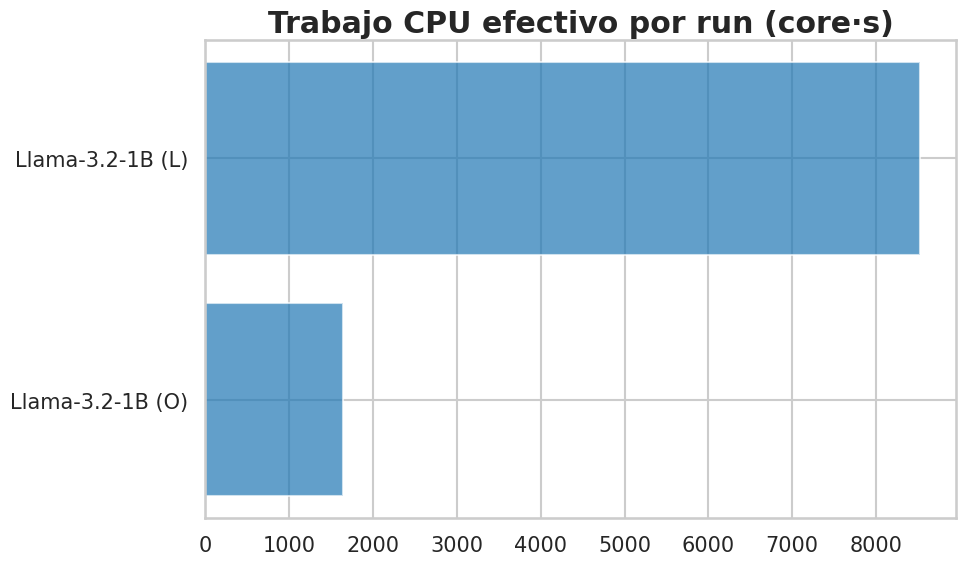

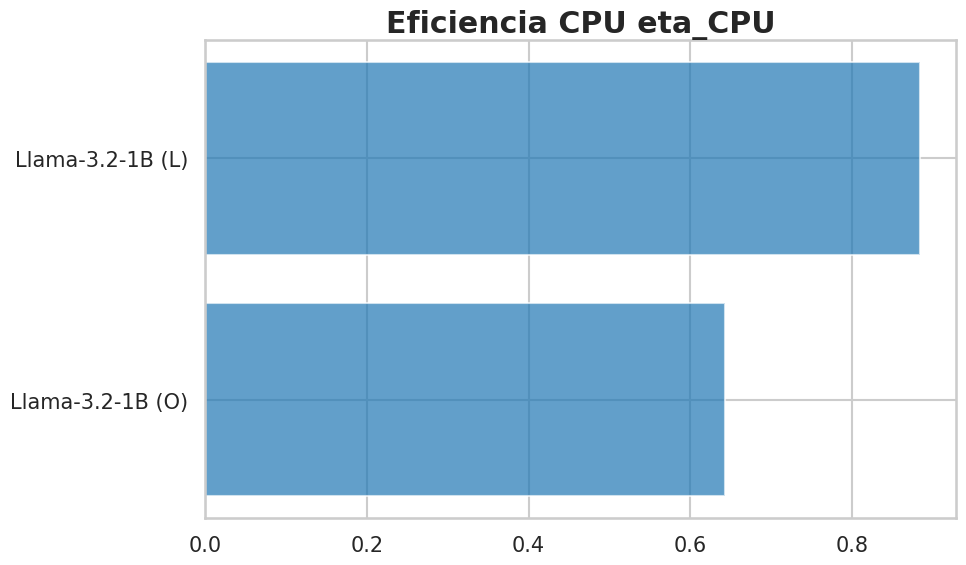

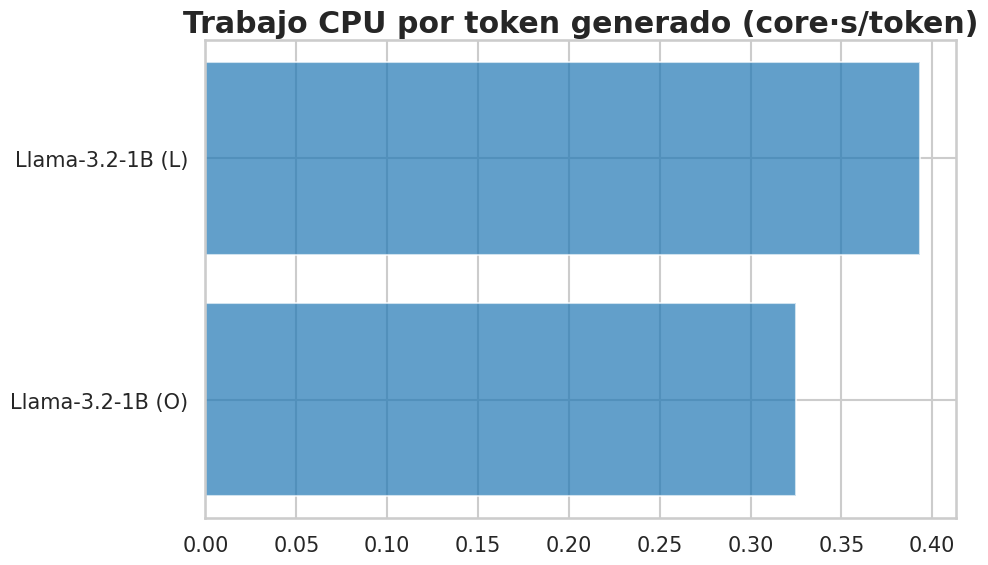

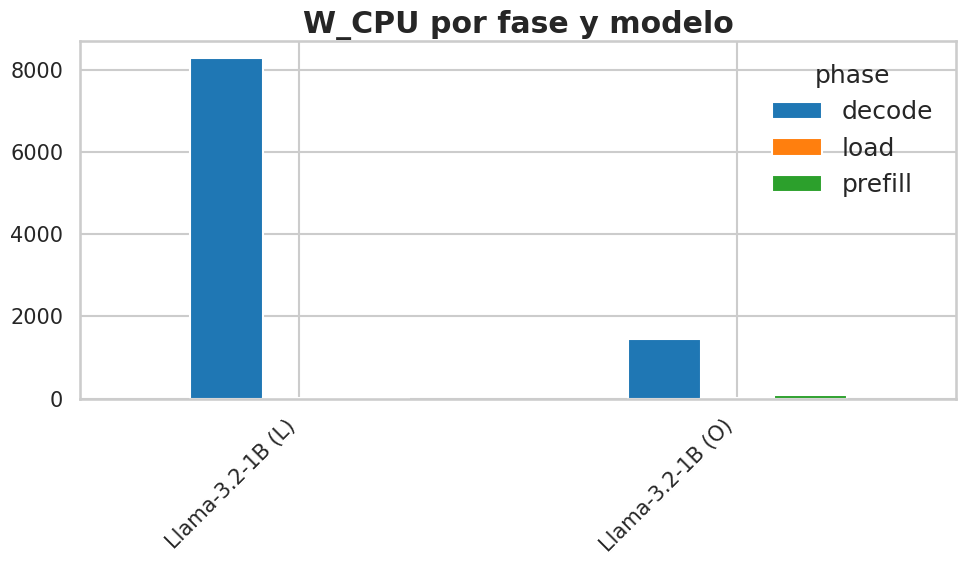

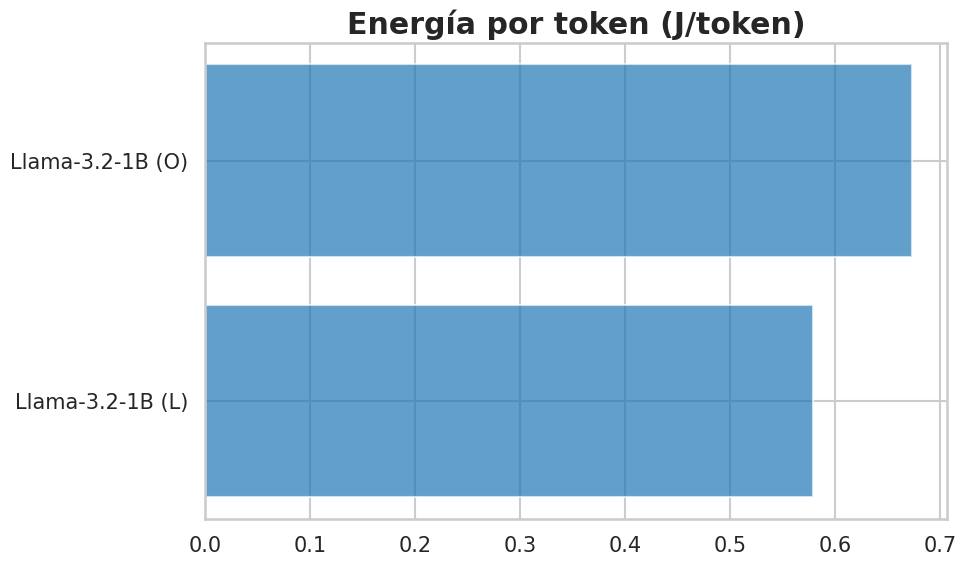

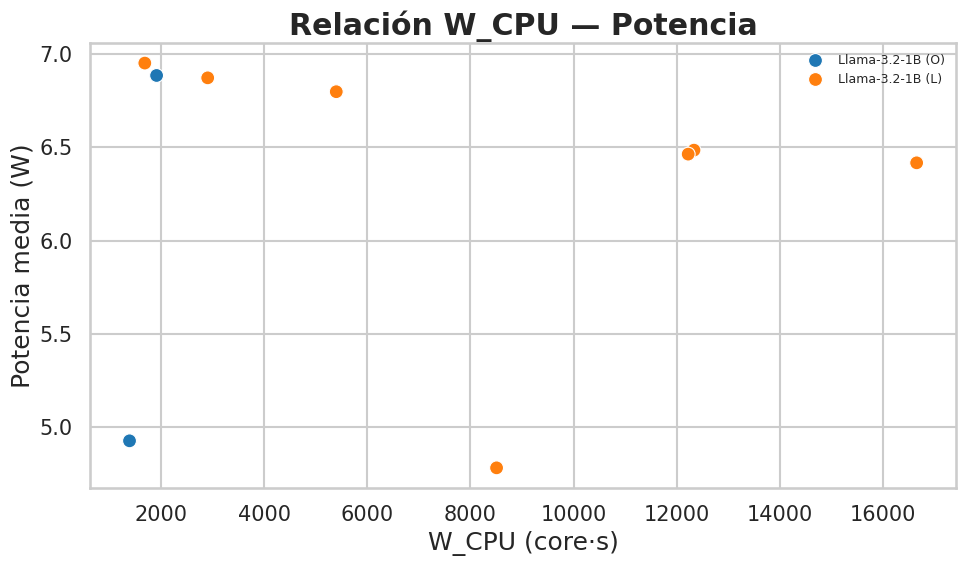

In [16]:
# Eficiencia computacional y energética
def _plot_metric(df, metric, ylabel, title, unit_divisor=1.0, unit_label="", order=None):
    data = df.dropna(subset=[metric]).copy()
    data["_val"] = data[metric] / unit_divisor
    counts = data.groupby("model_label")["_val"].count()
    min_n = counts.min() if not counts.empty else 0
    _order = order or data.groupby("model_label")["_val"].mean().sort_values().index.tolist()
    full_title = f"{title}" + (f" ({unit_label})" if unit_label else "")
    if min_n >= 3:
        fig, ax = plt.subplots(figsize=(10, 6))
        sns.barplot(data=data, x="model_label", y="_val", order=_order, ax=ax)
        ax.set_xticklabels(ax.get_xticklabels(), rotation=45, ha='right')
        ax.set_ylabel(unit_label or metric)
        ax.set_title(full_title)
        fig.tight_layout()
    else:
        means = data.groupby("model_label")["_val"].mean().reindex(_order)
        fig, ax = plt.subplots(figsize=(10, max(6, len(means) * 0.4)))
        ax.barh(range(len(means)), means, alpha=0.7)
        ax.set_yticks(range(len(means)))
        ax.set_yticklabels(means.index)
        ax.set_title(full_title)
        fig.tight_layout()
    plt.show()

for col, ylabel, title in [
    ("cpu_work_core_s", "core·s", "Trabajo CPU efectivo por run"),
    ("cpu_efficiency",  "",       "Eficiencia CPU eta_CPU"),
    ("cpu_work_per_token", "core·s/token", "Trabajo CPU por token generado"),
]:
    if col in ex.columns:
        _plot_metric(ex, col, ylabel=ylabel, title=title, unit_label=ylabel)

# Desglose por fases
try:
    phase_df = coll.cpu_work_by_phase_df() if hasattr(coll, "cpu_work_by_phase_df") else pd.DataFrame()
    phase_df_ex = phase_df[phase_df["run_id"].isin(ex["run_id"])] if not phase_df.empty else pd.DataFrame()
    if not phase_df_ex.empty:
        fig, ax = plt.subplots(figsize=(10, 6))
        phase_df_ex.groupby(["model_label", "phase"])["cpu_work_core_s"].mean().unstack().plot(
            kind="bar", ax=ax, rot=45)
        ax.set_title("W_CPU por fase y modelo")
        ax.set_xlabel("")
        ax.set_xticklabels(ax.get_xticklabels(), rotation=45, ha='right')
        fig.tight_layout()
        plt.show()
except Exception as e:
    print(f"cpu_work_by_phase_df: {e}")

# Energía por token
if "energy_per_token_j" in ex.columns:
    _plot_metric(ex, "energy_per_token_j", "J/token", "Energía por token", unit_label="J/token")

# Scatterplot CPU vs Potencia
if "cpu_work_core_s" in ex.columns and "power_mean_w" in ex.columns:
    valid_data = ex.dropna(subset=["cpu_work_core_s", "power_mean_w"])
    if not valid_data.empty:
        fig, ax = plt.subplots(figsize=(10, 6))
        sns.scatterplot(data=valid_data, x="cpu_work_core_s", y="power_mean_w",
                        hue="model_label", s=100, ax=ax)
        ax.set_xlabel("W_CPU (core·s)")
        ax.set_ylabel("Potencia media (W)")
        ax.set_title("Relación W_CPU — Potencia")
        ax.legend(fontsize=9)
        fig.tight_layout()
        plt.show()

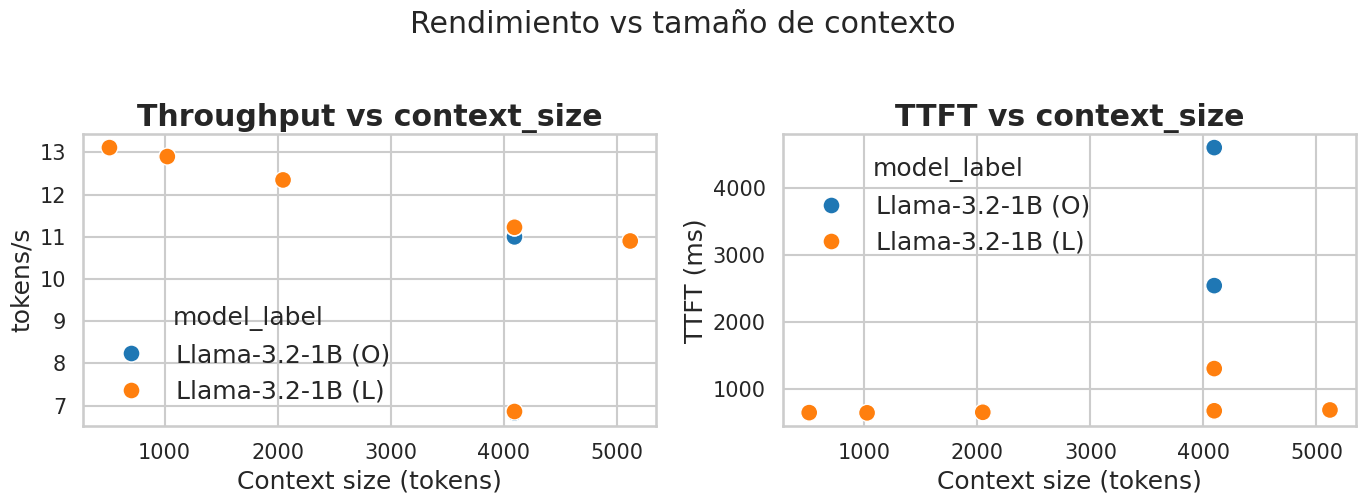

In [17]:
# Rendimiento vs context_size (E2)
if "context_size" in ex.columns and ex["context_size"].notna().any():
    fig, axes = plt.subplots(1, 2, figsize=(14, 5))
    ctx_data = ex.dropna(subset=["context_size"])
    sns.scatterplot(data=ctx_data, x="context_size", y="tokens_per_s_mean",
                    hue="model_label", s=150, ax=axes[0])
    axes[0].set_xlabel("Context size (tokens)")
    axes[0].set_ylabel("tokens/s")
    axes[0].set_title("Throughput vs context_size")
    sns.scatterplot(data=ctx_data, x="context_size", y="ttft_ms_mean",
                    hue="model_label", s=150, ax=axes[1])
    axes[1].set_xlabel("Context size (tokens)")
    axes[1].set_ylabel("TTFT (ms)")
    axes[1].set_title("TTFT vs context_size")
    fig.suptitle("Rendimiento vs tamaño de contexto", y=1.02)
    fig.tight_layout()
    plt.show()
else:
    print("Sin datos context_size para scatter")

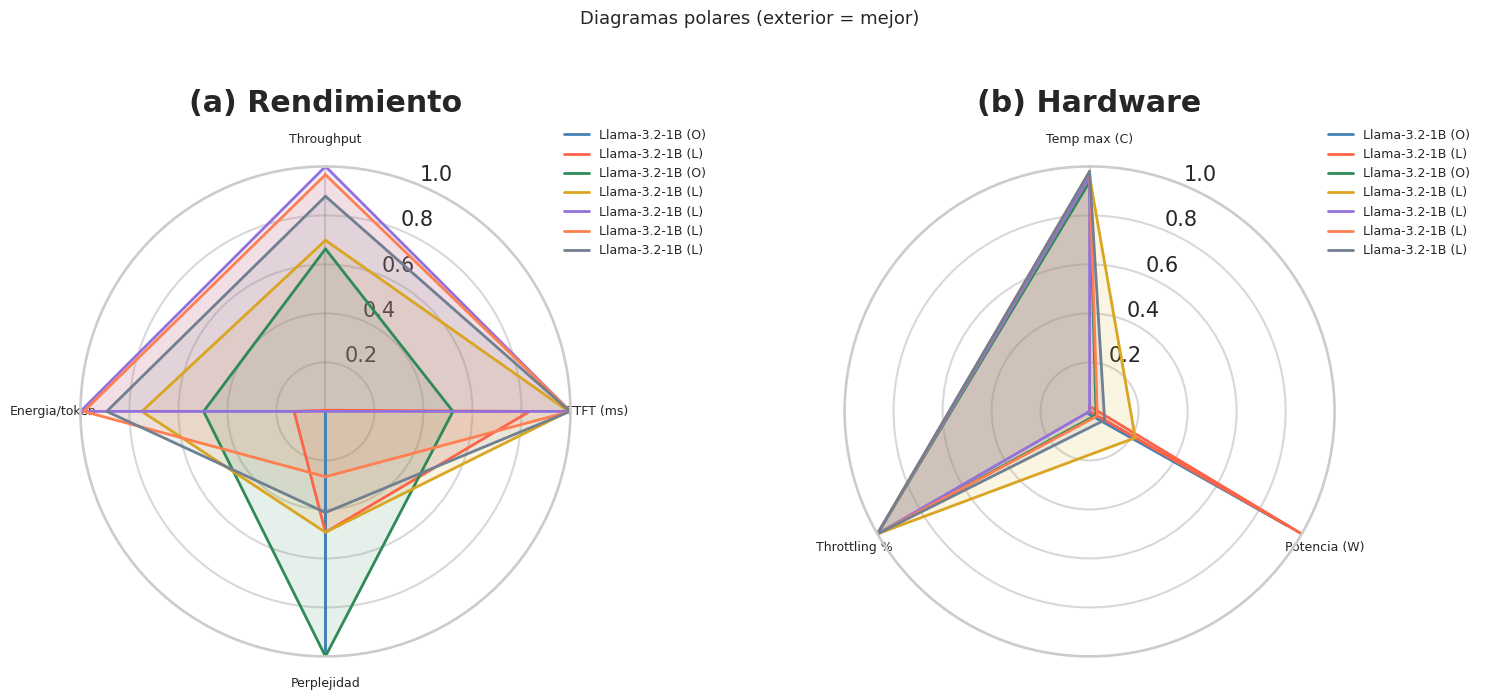

In [18]:
# Diagramas polares (rendimiento y hardware)
def _radar_chart(df, metrics, title, ax, colors):
    cols = [m[0] for m in metrics]
    data = df.dropna(subset=cols).copy()
    if data.empty:
        ax.text(0.5, 0.5, "Sin datos", ha="center", va="center", transform=ax.transAxes)
        return
    labels = [m[1] for m in metrics]
    N = len(metrics)
    angles = np.linspace(0, 2 * np.pi, N, endpoint=False).tolist()
    angles += angles[:1]
    ax.set_theta_offset(np.pi / 2)
    ax.set_theta_direction(-1)
    ax.set_xticks(angles[:-1])
    ax.set_xticklabels(labels, size=9)
    ax.set_ylim(0, 1)
    ax.grid(color="gray", alpha=0.3)
    ax.set_title(title, pad=15, fontweight="bold")
    for (_, row), color in zip(data.iterrows(), colors[:len(data)]):
        vals = []
        for col, _, higher_is_better in metrics:
            col_min, col_max = data[col].min(), data[col].max()
            rng = col_max - col_min if col_max != col_min else 1.0
            vals.append((data.loc[row.name, col] - col_min) / rng if higher_is_better
                        else (col_max - data.loc[row.name, col]) / rng)
        vals += vals[:1]
        ax.plot(angles, vals, lw=2, color=color, label=row["model_label"])
        ax.fill(angles, vals, alpha=0.12, color=color)
    ax.legend(loc="upper right", bbox_to_anchor=(1.3, 1.1), fontsize=9)

perf_metrics = [
    ("tokens_per_s_mean",  "Throughput",      True),
    ("ttft_ms_mean",       "TTFT (ms)",        False),
    ("perplexity_geomean", "Perplejidad",      False),
    ("energy_per_token_j", "Energia/token",    False),
]
hw_metrics_radar = [
    ("temp_max_c",      "Temp max (C)", False),
    ("power_mean_w",    "Potencia (W)", False),
    ("throttled_ratio", "Throttling %", False),
]
colors_radar = ["steelblue", "tomato", "seagreen", "goldenrod", "mediumpurple", "coral", "slategray"]
fig = plt.figure(figsize=(16, 7))
perf_avail = [m for m in perf_metrics if m[0] in ex.columns]
hw_avail   = [m for m in hw_metrics_radar if m[0] in ex.columns]
if perf_avail:
    ax1 = fig.add_subplot(121, polar=True)
    _radar_chart(ex, perf_avail, "(a) Rendimiento", ax1, colors_radar)
if hw_avail:
    ax2 = fig.add_subplot(122, polar=True)
    _radar_chart(ex, hw_avail, "(b) Hardware", ax2, colors_radar)
fig.suptitle("Diagramas polares (exterior = mejor)", fontsize=13, y=1.01)
plt.tight_layout()
plt.show()

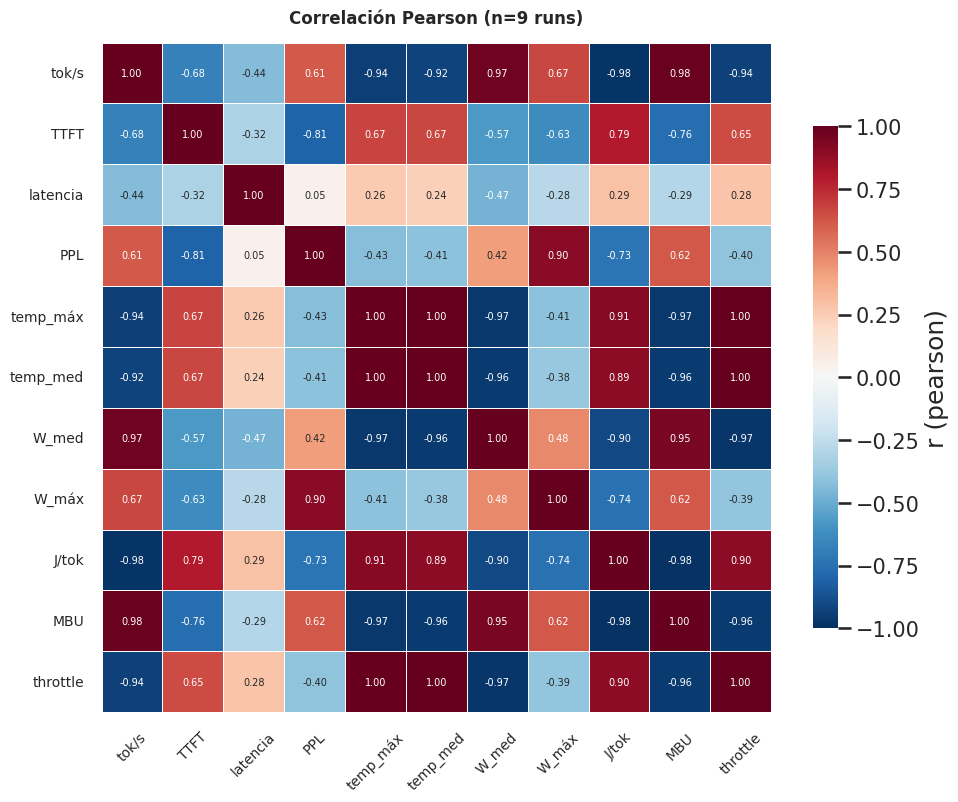

In [19]:
# Correlación de Pearson
try:
    from monitorviz.viz import correlation_heatmap
    if len(ex) >= 3:
        fig = correlation_heatmap(ex, title=f"Correlación Pearson (n={len(ex)} runs)")
        plt.show()
    else:
        print(f"Datos insuficientes: {len(ex)} run(s), se necesitan >=3.")
except Exception as e:
    print(f"Error en correlación: {e}")

In [20]:
# Alertas y anomalías
alerts = []
if "throttled_ratio" in ex.columns:
    for _, row in ex[ex["throttled_ratio"] > 0.5].iterrows():
        alerts.append(f"throttling: {row['model_label']} ({row['throttled_ratio']*100:.1f}%)")
if "n_empty_generations" in ex.columns:
    for _, row in ex[ex["n_empty_generations"] > 0].iterrows():
        alerts.append(f"generaciones vacias: {row['model_label']} (n={int(row['n_empty_generations'])})")
if "tokens_per_s_mean" in ex.columns and len(ex) >= 3:
    mean_tps = ex["tokens_per_s_mean"].mean()
    std_tps  = ex["tokens_per_s_mean"].std()
    for _, row in ex[(ex["tokens_per_s_mean"] > mean_tps + 2 * std_tps) |
                     (ex["tokens_per_s_mean"] < mean_tps - 2 * std_tps)].iterrows():
        alerts.append(f"outlier throughput: {row['model_label']} ({row['tokens_per_s_mean']:.2f} tok/s)")
for a in alerts:
    print(f"ALERTA: {a}")
if not alerts:
    print("Sin alertas detectadas")

ALERTA: throttling: Llama-3.2-1B (O) (98.7%)
ALERTA: throttling: Llama-3.2-1B (L) (99.9%)


## Conclusiones y discusión

### Confirmación/refutación de hipótesis
> TODO

### Hallazgos principales
> TODO

### Limitaciones
> TODO